# Task 2 - End Term Assessment SIT742: Modern Data Science



## Team  - 33 Members
#### Amayika - 24207774
#### Manoj Ravindran - 223918144
#### Yatharth Deoly 224207854

# Introduction to the Project
In this project, we are working on a dataset that consists of transaction records. The goal is to **perform data wrangling, aggregation, and analysis using PySpark and Pandas.** We'll process the data to extract insights regarding revenue, transaction patterns, and more. The dataset will be read from a .gz file, and we will use Spark for large-scale data handling while utilizing Pandas for additional manipulation and visualization.

## What is PySpark?
PySpark is the Python API for Apache Spark, a distributed computing framework designed for big data processing. It allows for efficient data handling over large datasets and provides multiple functionalities, including SQL operations, machine learning, and data wrangling, with great scalability. PySpark's core features include its speed, ability to process data in a distributed manner, and its resilience to failures. For this project, we will use PySpark for data wrangling and transformation, and leverage Pandas for visualization.



### Data Acquisition and Manipulation
There are total 2 parts in the assessment task. In the first part we will discuss few basic questions based on python and in the second part we will discuss some advanced version of Python.

Lets answer each part and each subpart one by one.

In [1]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.3-py2.py3-none-any.whl size=317840625 sha256=24a0e4b02014926ff130d32a1cec913ce2a445413b9ae2115b3b397fb68f0384
  Stored in directory: /root/.cache/pip/wheels/1b/3a/92/28b93e2fbfdbb07509ca4d6f50c5e407f48dce4ddbda69a4ab
Successfully built pyspark


## Importing all the necessary libraries for part - 1

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_replace
from pyspark.sql.functions import isnan, when, count, col
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import csv
import io
import gzip
from mlxtend.frequent_patterns import apriori, association_rules
from scipy.spatial.distance import pdist, squareform
from google.colab import drive
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

$NOTE$ - **Mounting the content or required file on the drive so that it can help us in initiating the path for zipped file.**

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


# Question 1.1 - Using PySpark to do some of the data wrangling process, so that:

## 1.1.1 For the ’NA’ in CustomerNo columns, change it to ’-1’.
## 1.1.2 Process the text in productName column, only alphabet characters left, and save the processed result to a new column productName_process and show the first 5 rows.

- For this part we have first Mounted the content on our drive
- The "transactionrecord.zip" data used for this part is downloaded from **here:** https://github.com/tulip-lab/sit742/blob/develop/Assessment/2024/data/transactionrecord.gz
- We are using spark to read the unzipped (csv) data for starting

In [4]:
# Initialize Spark session
spark = SparkSession.builder.appName("Data_Acquisition").getOrCreate()

# Load CSV data with local file system protocol
df_acquisition = spark.read.option("header", "true").csv("/content/drive/MyDrive/transactionrecord.gz",header=True)


In [5]:
df_acquisition.head()

Row(TransactionNo='581482', Date='12/9/2019', ProductNo='22485', ProductName='Set Of 2 Wooden Market Crates', Product_category='0ca', Price='21.47', Quantity='12', CustomerNo='17490', Country='United Kingdom')

### Explanation of code:

- It's setting up a tool called Spark, which is used for processing large amounts of data.
- The code gives this Spark setup a name: "Data_Acquisition".
- It then tells Spark to read a file named "transactionrecord.gz".
This file is a CSV that's been compressed to save space.
- The code specifies that the first row of the CSV contains column headers.
- Finally, it loads all this data into something called a DataFrame (df_acquisition), which is like a table in Spark that we can work with.

## 1.1.1 Changing 'NA' to '-1'

**Explanation of steps:**

- We will first check the null values in the column "CustomerNo"
- If Null values are present we will replace those values of "NA" with "-1" and we are using replace function for the same.
- In the end we will finally check our output

In [6]:
null_values = df_acquisition.filter(df_acquisition['CustomerNo'].isNull()).count()
null_values

0

In [7]:
# 1.1.1 Change 'NA' to '-1'
df_acquisition = df_acquisition.withColumn("CustomerNo", regexp_replace(col("CustomerNo"), "NA", "-1"))
df_acquisition

DataFrame[TransactionNo: string, Date: string, ProductNo: string, ProductName: string, Product_category: string, Price: string, Quantity: string, CustomerNo: string, Country: string]

In [8]:
# Printing all rows where 'CustomerNo' is either null or 'NA'
df_acquisition.filter((col("CustomerNo").isNull()) | (col("CustomerNo") == "NA")).show()

+-------------+----+---------+-----------+----------------+-----+--------+----------+-------+
|TransactionNo|Date|ProductNo|ProductName|Product_category|Price|Quantity|CustomerNo|Country|
+-------------+----+---------+-----------+----------------+-----+--------+----------+-------+
+-------------+----+---------+-----------+----------------+-----+--------+----------+-------+



In [9]:
# Printing rows where 'CustomerNo' is either null or 'NA'
df_acquisition.filter((col("CustomerNo").isNull()) | (col("CustomerNo") == "-1")).show()

+-------------+----------+---------+--------------------+----------------+-----+--------+----------+--------------+
|TransactionNo|      Date|ProductNo|         ProductName|Product_category|Price|Quantity|CustomerNo|       Country|
+-------------+----------+---------+--------------------+----------------+-----+--------+----------+--------------+
|      C581406| 12/8/2019|   46000M|Polyester Filler ...|             0ca| 6.19|    -240|        -1|United Kingdom|
|      C581406| 12/8/2019|   46000S|Polyester Filler ...|             0ca| 6.19|    -300|        -1|United Kingdom|
|      C575153| 11/8/2019|    22947|Wooden Advent Cal...|             0ca|44.25|      -1|        -1|United Kingdom|
|      C574288| 11/3/2019|    22178|Victorian Glass H...|             0ca|25.37|      -1|        -1|United Kingdom|
|      C573180|10/28/2019|    23048|Set Of 10 Lantern...|             0ca| 14.5|      -1|        -1|United Kingdom|
|      C569495| 10/4/2019|    21843|Red Retrospot Cak...|             0c

### Output
So, here we have checked all those "CustomerNo" where its "NA" and "-1" after replacement and we can see that there are no such rows where the CustomerNo" is "NA"

## 1.1.2 Keep only alphabet characters in productName and create new column

We are following the given steps:

### Explanation of Code:
- It creates a new column named "productName_process".
- This new column contains the text from "productName", but with all non-alphabet characters removed and it uses a function called regexp_replace to do this removal.
- Finally, it displays the first 5 rows of the updated table.

In [10]:
# 1.1.2 Keep only alphabet characters in productName and create new column
df_acquisition = df_acquisition.withColumn("productName_process", regexp_replace(col("productName"), "[^a-zA-Z]", ""))
df_acquisition.show(5)


+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+--------------------+
|TransactionNo|     Date|ProductNo|         ProductName|Product_category|Price|Quantity|CustomerNo|       Country| productName_process|
+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+--------------------+
|       581482|12/9/2019|    22485|Set Of 2 Wooden M...|             0ca|21.47|      12|     17490|United Kingdom|SetOfWoodenMarket...|
|       581475|12/9/2019|    22596|Christmas Star Wi...|             0ca|10.65|      36|     13069|United Kingdom|ChristmasStarWish...|
|       581475|12/9/2019|    23235|Storage Tin Vinta...|             0ca|11.53|      12|     13069|United Kingdom|StorageTinVintage...|
|       581475|12/9/2019|    23272|Tree T-Light Hold...|             0ca|10.65|      12|     13069|United Kingdom|TreeTLightHolderW...|
|       581475|12/9/2019|    23239|Set Of 4 Knic

### Output explanation:
- The output shows a table with 10 columns.
- Each row represents a transaction.
- The last column, "productName_process", contains the product names with only letters.
- Spaces and any special characters have been removed from the product names.

# 1.2 Find out the revenue on each transaction date. In order to achieve the above, some wrangling work is required to be done:
### 1.2.1 Using pyspark to calculate the revenue (price * Quantity) and save as float format in pyspark dataframe to show the top 5 rows.

**Explanation of Code**
- We import the col function from pyspark.sql.functions to reference columns in our calculations.
- We create a new column called "revenue" using withColumn().
- Inside withColumn(), we multiply the "price" column by the "Quantity" column.
- We cast the result to float using .cast("float") to ensure the revenue is in float format.
- Finally, we show the top 5 rows of the resulting DataFrame.


In [11]:
# 1.2.1 Calculate revenue
df_acquisition = df_acquisition.withColumn("revenue", (col("price") * col("Quantity")).cast("float"))

# Show top 5 rows
df_acquisition.show(5)

+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+--------------------+-------+
|TransactionNo|     Date|ProductNo|         ProductName|Product_category|Price|Quantity|CustomerNo|       Country| productName_process|revenue|
+-------------+---------+---------+--------------------+----------------+-----+--------+----------+--------------+--------------------+-------+
|       581482|12/9/2019|    22485|Set Of 2 Wooden M...|             0ca|21.47|      12|     17490|United Kingdom|SetOfWoodenMarket...| 257.64|
|       581475|12/9/2019|    22596|Christmas Star Wi...|             0ca|10.65|      36|     13069|United Kingdom|ChristmasStarWish...|  383.4|
|       581475|12/9/2019|    23235|Storage Tin Vinta...|             0ca|11.53|      12|     13069|United Kingdom|StorageTinVintage...| 138.36|
|       581475|12/9/2019|    23272|Tree T-Light Hold...|             0ca|10.65|      12|     13069|United Kingdom|TreeTLightHolderW...| 

#### Output - Finally, we show the top 5 rows of the resulting DataFrame.

## 1.2.2 Converting to Pandas DataFrame -  Transform the pyspark dataframe to pandas dataframe (named as df) and create the column transaction_date with date format according to Date. Print your df pandas dataframe with top 5 rows after creating the column transaction_date.

#### Steps we are performing -
- We will first convert the data into pandass data frame.
- Then we will try to know our data set, including all the basics of it which includes its shape, information, any ambiguity in the data set.
- This will help us in further analysis after knowing the information and summary of the data set.
- We are using "toPandas" function for the conversion.

In [12]:
# 1.2.2 Convert to Pandas DataFrame

df = df_acquisition.toPandas()
df.head(5)

,TransactionNo,Date,ProductNo,ProductName,Product_category,Price,Quantity,CustomerNo,Country,productName_process,revenue
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,0ca,21.47,12,17490,United Kingdom,SetOfWoodenMarketCrates,257.640015
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,0ca,10.65,36,13069,United Kingdom,ChristmasStarWishListChalkboard,383.399994
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,0ca,11.53,12,13069,United Kingdom,StorageTinVintageLeaf,138.360001
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,0ca,10.65,12,13069,United Kingdom,TreeTLightHolderWillieWinkie,127.800003
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,0ca,11.94,6,13069,United Kingdom,SetOfKnickKnackTinsPoppies,71.639999


In [13]:
df.shape

(536350, 11)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TransactionNo        536350 non-null  object 
 1   Date                 536350 non-null  object 
 2   ProductNo            536350 non-null  object 
 3   ProductName          536350 non-null  object 
 4   Product_category     536350 non-null  object 
 5   Price                536350 non-null  object 
 6   Quantity             536350 non-null  object 
 7   CustomerNo           536350 non-null  object 
 8   Country              536350 non-null  object 
 9   productName_process  536350 non-null  object 
 10  revenue              536350 non-null  float32
dtypes: float32(1), object(10)
memory usage: 43.0+ MB


In [15]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [16]:
df.isnull().sum()

,0
TransactionNo,0
Date,0
ProductNo,0
ProductName,0
Product_category,0
Price,0
Quantity,0
CustomerNo,0
Country,0
productName_process,0


### Basic Understanding of data set
1. Size: The dataset contains 536,350 rows and 11 columns.
2. It appears to be a sales or transaction dataset, likely for an e-commerce or retail business.
3. Key columns:
  - TransactionNo: Unique identifier for each transaction
  - Date: When the transaction occurred
  - ProductNo and ProductName: Identifiers for the products sold
  - Price and Quantity: Details of the sale
  - CustomerNo: Identifier for the customer
  - Country: Where the transaction took place
  - Revenue: Calculated field (which we added after calculating Price * Quantity)

4. Data types: Most columns (10 out of 11) are stored as 'object' type, which typically means they contain strings. The 'revenue' column is stored as "float32."
5. There are no null values in any column, suggesting a clean and complete dataset.
6. The column 'productName_process', which we have cleaned and its a standardized version of the product name.
7. This dataset is well-suited for analyzing sales patterns, customer behavior and product performance.
8. **The column "Date" is stored in object data type so, we are first going to change this into "DateTime" format after creating the column "transaction_date" before moving ahead with pattern and trend analysis.**
9. Also, we are correcting the data types of two columns that is "Price" and "Quantity" into numeric data types.

In [17]:
df['transaction_date'] = pd.to_datetime(df['Date'])
df.head()

,TransactionNo,Date,ProductNo,ProductName,Product_category,Price,Quantity,CustomerNo,Country,productName_process,revenue,transaction_date
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,0ca,21.47,12,17490,United Kingdom,SetOfWoodenMarketCrates,257.640015,2019-12-09
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,0ca,10.65,36,13069,United Kingdom,ChristmasStarWishListChalkboard,383.399994,2019-12-09
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,0ca,11.53,12,13069,United Kingdom,StorageTinVintageLeaf,138.360001,2019-12-09
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,0ca,10.65,12,13069,United Kingdom,TreeTLightHolderWillieWinkie,127.800003,2019-12-09
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,0ca,11.94,6,13069,United Kingdom,SetOfKnickKnackTinsPoppies,71.639999,2019-12-09


## 1.2.3 Plot the sum of revenue on transaction_date in a line plot and find out any immediate pattern / insight?

- We will check the information of data set initially to understand the new processed data set.
- As We have added a new  column "transcation_date" which is of "DateTime" format, we are going to use this column for pattern analysis.


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   TransactionNo        536350 non-null  object        
 1   Date                 536350 non-null  object        
 2   ProductNo            536350 non-null  object        
 3   ProductName          536350 non-null  object        
 4   Product_category     536350 non-null  object        
 5   Price                536350 non-null  float64       
 6   Quantity             536350 non-null  int64         
 7   CustomerNo           536350 non-null  object        
 8   Country              536350 non-null  object        
 9   productName_process  536350 non-null  object        
 10  revenue              536350 non-null  float32       
 11  transaction_date     536350 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float32(1), float64(1), int64(1), object(8)
memory

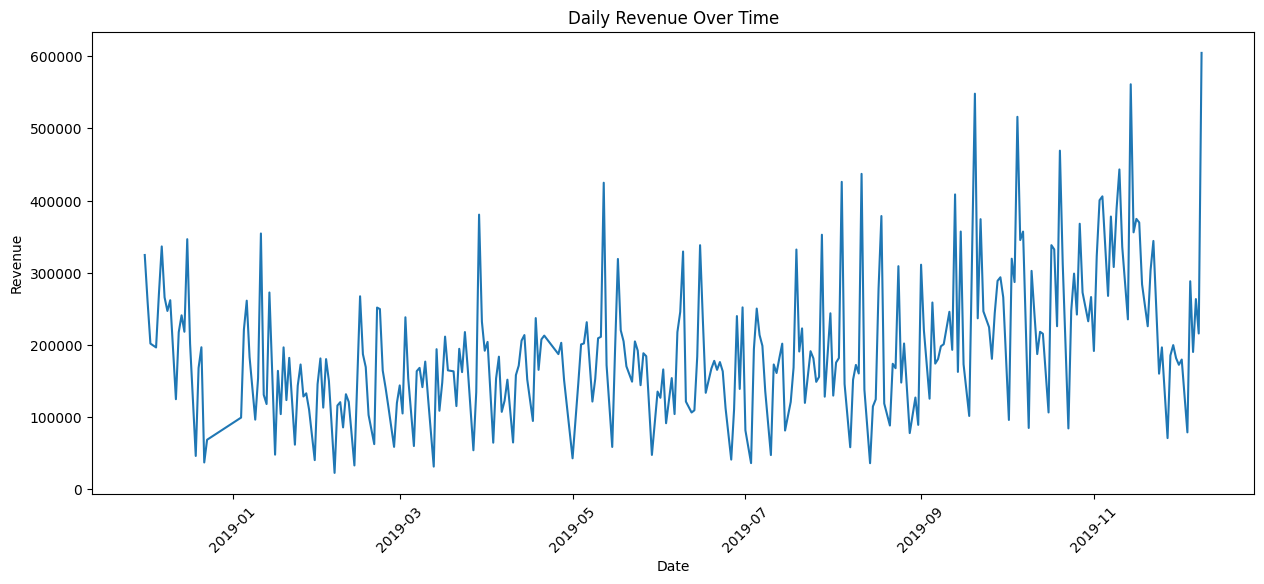

In [20]:
# Group by transaction_date and sum revenue
daily_revenue = df.groupby('transaction_date')['revenue'].sum().reset_index()

# Plot
plt.figure(figsize=(15,6))
plt.plot(daily_revenue['transaction_date'], daily_revenue['revenue'])
plt.title('Daily Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


### Explanation of code and insights from the output graph:

- Our code Groups the data by "transaction_date" and sums "revenue" for each day
- Then it Creates a line plot of daily revenue over time
- Sets the title, labels, and rotates x-axis labels for readability

### Output explanation:
- The graph shows daily revenue from late 2018 to late 2019
- Y-axis represents revenue, ranging from 0 to about 600,000
- X-axis shows dates, with labels rotated 45 degrees
- The line represents how revenue fluctuates each day

### Key Insights:
- Revenue is highly variable day-to-day
- There's an overall upward trend in revenue over time
- Some days show significantly higher revenue spikes
- The highest revenue spike appears to be near the end of 2019, reaching around 600,000

# Question 1.3- Let’s continue to analyse on the transaction_date vs revenue.

## 1.3.1 Determine which workday (day of the week), generates the most sales (plotting the results in a line chart with workday on averaged revenues).

### Explanation of code:
- We create a new column called 'day_of_week' that tells us which day of the week each transaction happened.
- We then group all transactions by the day of the week and calculate the average revenue for each day.
- We find out which day has the highest average revenue and print it.
- We make sure our days are in order from Monday to Sunday.
Finally, we create a line graph to show this information visually.

In [21]:
# Create a new column for day of the week
df['day_of_week'] = df['transaction_date'].dt.day_name()

# Group by day of the week and calculate average revenue
avg_revenue_by_day = df.groupby('day_of_week')['revenue'].mean().reset_index()

# Identify the day with the highest average revenue
most_profitable_day = avg_revenue_by_day.loc[avg_revenue_by_day['revenue'].idxmax(), 'day_of_week']
print(f"The most profitable day is: {most_profitable_day}")


The most profitable day is: Sunday


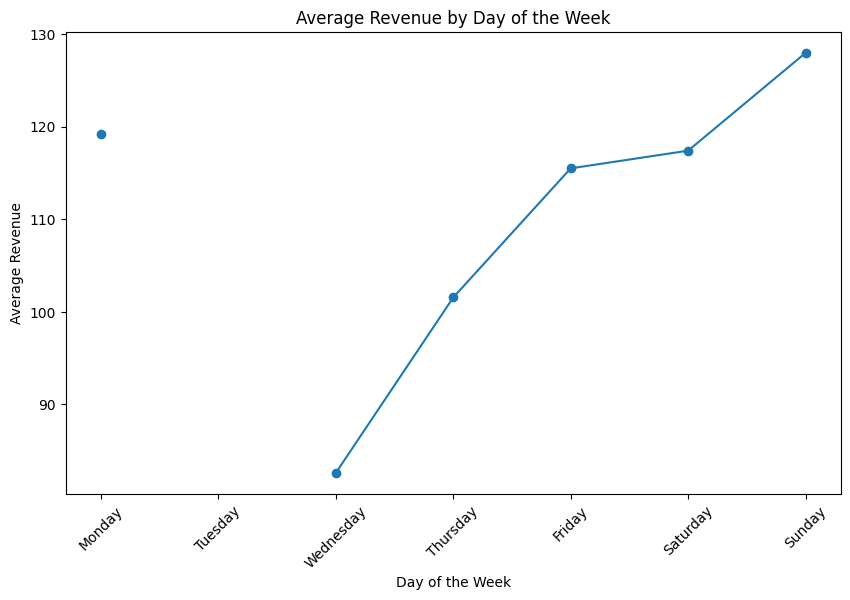

In [22]:
# Create a new column for day of the week
df['day_of_week'] = df['transaction_date'].dt.day_name()

# Group by day of the week and calculate average revenue
avg_revenue_by_day = df.groupby('day_of_week')['revenue'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).reset_index()

# Plot
plt.figure(figsize=(10,6))
plt.plot(avg_revenue_by_day['day_of_week'], avg_revenue_by_day['revenue'],marker='o', linestyle='-')
plt.title('Average Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.show()


### Insights obtained from Graph Explanation:
1. The graph shows the average revenue for each day of the week.
2. The x-axis shows the days from Monday to Sunday and the y-axis shows the average revenue, ranging from about 80 to 130
3. **There's a clear increase in revenue as we move towards the weekend, with Sunday having the highest average revenue.** The weekend peak (especially Sunday) could be due to people having more free time to shop.
4. Wednesday has the lowest average revenue, creating a V-shape in the middle of the week. The midweek dip might be because people are focused on work and less likely to make purchases.
5. Monday Anomaly: Interestingly, Monday has the second-highest average revenue, which is unexpected and might be worth investigating further.
6. From Wednesday to Sunday, there's a steady increase in average revenue each day.

## 1.3.2 - Identify the name of product (column productName_process) that contributes the highest revenue on ‘that workday’ (you need to find out from 1.3.1) and the name of product (column productName_process) that has the highest sales volume (sum of the Quantity), no need to remove negative quantity transactions.) on ‘that workday’ (you need to find out from 1.3.1).

Let's start by identifying the day of the week with the highest average revenue:

### Now, based on this most_profitable_day, find the product with the highest revenue and sales volume.
**Explanation of Code**
- It first determines the most profitable day of the week, as we did in the previous analysis.
- It then filters the DataFrame to include only transactions from that most profitable day.
- For the highest revenue product:
  - It groups the filtered data by product name and sums the revenue for each product.
  - It finds the product with the maximum total revenue.
- For the highest sales volume product:
  - It groups the filtered data by product name and sums the quantity sold for each product.
  - It finds the product with the maximum total quantity sold.
- Finally, it prints out the results, showing:
  - The most profitable day
  - The product with the highest revenue on that day, along with its revenue
  - The product with the highest sales volume on that day, along with its total quantity sold.

In [23]:
# 1. Determine the most profitable day (from previous analysis)
avg_revenue_by_day = df.groupby('day_of_week')['revenue'].mean().reset_index()
most_profitable_day = avg_revenue_by_day.loc[avg_revenue_by_day['revenue'].idxmax(), 'day_of_week']

print(f"The most profitable day is: {most_profitable_day}")

# 2. Filter data for the most profitable day
df_most_profitable = df[df['day_of_week'] == most_profitable_day]

The most profitable day is: Sunday


### Finding the product with the highest revenue on the most profitable day that is Sunday

In [24]:
# Find the product with the highest revenue on the most profitable day
highest_revenue_product = df_most_profitable.groupby('productName_process')['revenue'].sum().idxmax()
highest_revenue = df_most_profitable.groupby('productName_process')['revenue'].sum().max()

print(f"Product with highest revenue on {most_profitable_day}: {highest_revenue_product}")
print(f"Revenue: {highest_revenue:.2f}")

Product with highest revenue on Sunday: WorldWarGlidersAsstdDesigns
Revenue: 187081.34


### Finding the product with the highest sales volume on the most profitable day that is Sunday

In [25]:
highest_quantity_product = df_most_profitable.groupby('productName_process')['Quantity'].sum()
highest_quantity_product

,Quantity
productName_process,
APrettyThankYouCard,49
AWallTidyBlueOffice,5
AbcTreasureBookBox,588
AbstractCircleJournal,30
AbstractCirclesPocketBook,47
...,...
dSheetOfDogStickers,78
dTraditionalChristmasStickers,303
dVintageChristmasStickers,310


In [26]:
# 4. Find the product with the highest sales volume on the most profitable day
highest_sales_volume_product = df_most_profitable.groupby('productName_process')['Quantity'].sum().idxmax()
highest_volume = df_most_profitable.groupby('productName_process')['Quantity'].sum().max()

print(f"Product with highest sales volume on {most_profitable_day}: {highest_sales_volume_product}")
print(f"Total quantity sold: {highest_volume}")

Product with highest sales volume on Sunday: WorldWarGlidersAsstdDesigns
Total quantity sold: 18051


### Insights from the Output:

1. **Most Profitable Day: Sunday**
- Based on the analysis of revenue, the most profitable day of the week is Sunday. This implies that customers tend to spend the most on this particular day, making it a key time for sales and revenue generation.

2. **Product with the Highest Revenue on Sunday:** The product that generates the highest revenue on Sunday is **"WorldWarGlidersAsstdDesigns"** with a total revenue of 187,081.34. This indicates that this specific product is very popular on Sundays, contributing significantly to the company's revenue.

3. **Product with the Highest Sales Volume on Sunday:** Interestingly, the product that also has the highest sales volume (based on quantity sold) on Sunday is the same product: **"WorldWarGlidersAsstdDesigns"** This suggests that the popularity of this product is not just based on high prices but also on a high number of units sold.


# 1.3.3 - Plot Top 5 Products with Highest Revenues and Sales Volumes
### Now, let's plot the top 5 products with the highest revenues:

**Explanation of code**
1. Data analysis: It groups the data by product name, sums up the revenue for each product, and finds the top 5 products with the highest total revenue.
2. Visualization: It creates a bar chart showing these top 5 products and their revenue.
3. The chart uses blue bars to represent each product's revenue, with product names on the x-axis (tilted 45 degrees for readability) and revenue amounts on the y-axis

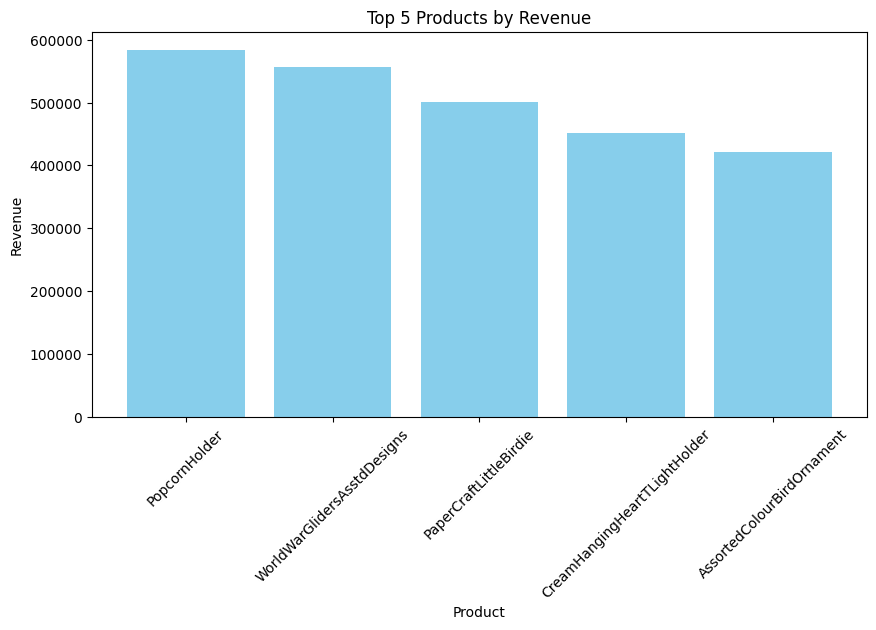

In [27]:
# Sort products by revenue and quantity
top_5_revenue_products = df.groupby('productName_process')['revenue'].sum().nlargest(5).reset_index()

# Plot top 5 products by revenue
plt.figure(figsize=(10,5))
plt.bar(top_5_revenue_products['productName_process'], top_5_revenue_products['revenue'], color='skyblue')
plt.title('Top 5 Products by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()


### Let's plot the top 5 products with the sales volumes:

**Explanation of code**
1. Data analysis: It groups the data by product name, sums up the quantity for each product, and finds the top 5 products with the highest total quantity.
2. Visualization: It creates a bar chart showing these top 5 products and their sales volume.
3. The chart uses blue bars to represent each product's sales, with product names on the x-axis (tilted 45 degrees for readability) and sales amounts on the y-axis

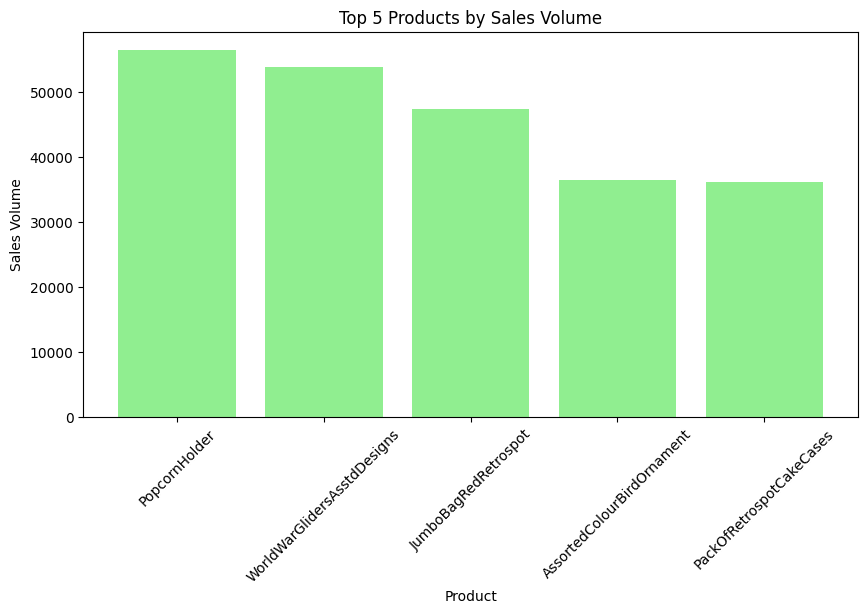

In [28]:
# Sort products by revenue and quantity
top_5_sales_volume_products = df.groupby('productName_process')['Quantity'].sum().nlargest(5).reset_index()

# Plot top 5 products by sales volume
plt.figure(figsize=(10,5))
plt.bar(top_5_sales_volume_products['productName_process'], top_5_sales_volume_products['Quantity'], color='lightgreen')
plt.title('Top 5 Products by Sales Volume')
plt.xlabel('Product')
plt.ylabel('Sales Volume')
plt.xticks(rotation=45)
plt.show()


### Insights from the Graphs obtained:

1. Revenue vs. Sales Volume: The top 2 products (Popcornholder and WorldwideGliders&setDesigns) are the same for both revenue and sales volume.
This suggests these products are both high-selling and high-revenue generators.
2. Product Performance:
  - Popcornholder is the clear leader in both revenue and sales volume.
  - WorldwideGliders&setDesigns is a strong second in both categories.

3. Variations: Some products appear in the top 5 for revenue but not for sales volume (e.g., PaperCraftLittleBirdie, CreamHangingHeartLightholder) and vice- versa. This indicates differences in pricing or profit margins among products.
4. Revenue Range:
  - The top product by revenue (Popcornholder) generates about 600,000 in revenue.
  - The 5th ranked product (AssortedColourbirdOrnament) generates around 400,000.
5. Sales Volume Range:
  - The highest selling product (Popcornholder) has about 57,000 units sold.
  - The 5th ranked product (PackOfRetroSpotCakeCase) has about 37,000 units sold.

# Question 1.4 - Which country generates the highest revenue? Additionally, identify the month in that country that has the highest revenue.

## Which country generates the highest revenue?
### Explanation of the Code:

1. Finding the Country with the Highest Revenue: We group the data by the Country column and sum the revenue for each country.
2. We use idxmax() to find the country with the highest total revenue.
3. Filtering Data for the Highest Revenue Country: After identifying the highest-revenue country, we filter the dataset to include only records from that country.

In [29]:
# Finding the country that generates the highest revenue
country_revenue = df.groupby('Country')['revenue'].sum().reset_index()
highest_revenue_country = country_revenue.loc[country_revenue['revenue'].idxmax()]

print(f"The country with the highest revenue is: {highest_revenue_country['Country']}")
print(f"Total revenue: {highest_revenue_country['revenue']:.2f}")

The country with the highest revenue is: United Kingdom
Total revenue: 49994032.00


### Additionally, identify the month in that country that has the highest revenue.

Identify the month with the highest revenue in that country by filtering the data for that specific country, extracting the month from the transaction date, and summing the revenue for each month.

### Explanation of code:

1. Extracting the Month: We create a new column Month from the transaction_date by extracting the month.
2. Finding the Month with the Highest Revenue: We group the data by Month and sum the revenue for each month.
3. Again, we use idxmax() to find the month with the highest revenue.
4. The line highest_revenue_month_name = highest_revenue_month['Month'].strftime('%B') converts the Month period to a datetime object and formats it to show only the month's name (e.g., November instead of "2019-11").

In [30]:
# Filtering the data for the country with the highest revenue
df_highest_country = df[df['Country'] == highest_revenue_country['Country']].copy()

# Extracting month from the transaction date
df_highest_country.loc[:, 'Month'] = df_highest_country['transaction_date'].dt.to_period('M')

# Finding the month with the highest revenue in the highest-revenue country
month_revenue = df_highest_country.groupby('Month')['revenue'].sum().reset_index()
highest_revenue_month = month_revenue.loc[month_revenue['revenue'].idxmax()]

# Convert period to datetime and then extract only the month name
highest_revenue_month_name = highest_revenue_month['Month'].strftime('%B')

print(f"The month with the highest revenue in {highest_revenue_country['Country']} is: {highest_revenue_month_name}")
print(f"Revenue in that month: {highest_revenue_month['revenue']:.2f}")


The month with the highest revenue in United Kingdom is: November
Revenue in that month: 6737640.00


### Outputs:
- The country with the highest revenue is **United Kingdom**
- Total revenue generated from the country is **49994032.00**
- Now if we talk month wise we get to see that The month with the highest revenue in United Kingdom is 11th month that is **November**
- Revenue generated in that month is **6737640.00**

# Question 1.5: Let’s do some analysis on the CustomerNo and their transactions. Determine the shopping frequency of customers to identify who shops most frequently (find out the highest distinct count of transactionNo on customer level, be careful with those transactions that is not for shopping – filter those transaction quantity <= 0). Also, find out what products (column productName_process) ‘this customer’ typically buys based on the Quantity of products purchased.


### Steps we are going to follow:
1. Filter out non-shopping transactions where the Quantity is less than or equal to 0.
2. Determine the shopping frequency by counting the distinct TransactionNo for each customer.
3. Find the customer with the highest shopping frequency (most transactions).
4. For the customer with the highest shopping frequency, analyze the products they typically buy based on the sum of Quantity.

### Explanation of code:
1. Filtering transactions: We filter out transactions where Quantity is less than or equal to 0 because these are not valid shopping transactions.
2. Shopping frequency: We group by CustomerNo and use nunique() on TransactionNo to count the distinct transactions for each customer.
3. Identify most frequent shopper: The customer with the highest distinct transaction count is identified using idxmax().
4. Analyze typical products: For the most frequent customer, we group the data by productName_process and sum the Quantity to identify what products they typically buy.

In [31]:
# Step 1: Filter out transactions with Quantity <= 0
df_shopping = df[df['Quantity'] > 0].copy()

# Step 2: Group by CustomerNo and count distinct TransactionNo to find shopping frequency
shopping_frequency = df_shopping.groupby('CustomerNo')['TransactionNo'].nunique().reset_index()

# Step 3: Find the customer with the highest distinct count of TransactionNo (most frequent shopper)
most_frequent_customer = shopping_frequency.loc[shopping_frequency['TransactionNo'].idxmax()]
most_frequent_customer_no = most_frequent_customer['CustomerNo']
print(f"The customer who shops most frequently is CustomerNo: {most_frequent_customer_no}")

# Step 4: Find out what products this customer typically buys based on Quantity
# Filter data for the most frequent customer
df_most_frequent_customer = df_shopping[df_shopping['CustomerNo'] == most_frequent_customer_no]

# Group by productName_process and sum up the Quantity for each product
customer_frequent_products = df_most_frequent_customer.groupby('productName_process')['Quantity'].sum().reset_index()

# Sort products by Quantity in descending order to see what they typically buy
customer_frequent_products = customer_frequent_products.sort_values(by='Quantity', ascending=False)

print(f"Products typically bought by CustomerNo {most_frequent_customer_no}:")
print(customer_frequent_products.head())  # Display top products by Quantity


The customer who shops most frequently is CustomerNo: 12748
Products typically bought by CustomerNo 12748:
                productName_process  Quantity
1609   VictorianMetalPostcardSpring       595
1706    WorldWarGlidersAsstdDesigns       480
1273  RoseScentCandleJewelledDrawer       408
201         CartoonPencilSharpeners       405
1483    SmallWhiteRetrospotMugInBox       390


In [32]:
customer_frequent_products

,productName_process,Quantity
1609,VictorianMetalPostcardSpring,595
1706,WorldWarGlidersAsstdDesigns,480
1273,RoseScentCandleJewelledDrawer,408
201,CartoonPencilSharpeners,405
1483,SmallWhiteRetrospotMugInBox,390
...,...,...
989,PantryAppleCorer,1
507,FrenchCarriageLantern,1
508,FrenchChateauLargePlatter,1
986,PairOfPinkFlowerClusterSlide,1


In [33]:
customer_frequent_products.shape

(1750, 2)


### Insights from the output obtained:

- **The customer who shops most frequently is CustomerNo: 12748.**
- This customer frequently purchases a variety of products, with the most commonly bought items being:
  - Victorian Metal Postcard Spring (Quantity: 595)
  - World War Gliders Assorted Designs (Quantity: 480)
  - Rose Scent Candle Jewelled Drawer (Quantity: 408)
These products indicate the customer's preference for decorative and novelty items. The high quantities suggest they either shop in bulk or regularly restock these specific items.
  - Customer frequent products data frame has 1750 attributes and 2 variables.

# Question 1.6: As the data scientist, you would like to build a basket-level analysis on the product customer buying (filter the ‘df’ dataframe with df[’Quantity’]>0). In this task, you need to:

## 1.6.1 Group by the transactionNo and aggregate the category of product (column product_category) into list on transactionNo level. Similarly, group and aggregate name of product (column productName_process) into list on transactionNo level

**Explanation of code:**
1. Filtering Data: We first filter the dataframe to exclude transactions with negative or zero quantities (Quantity > 0).
2. Grouping Data (df_agg):
  - We group the filtered data by TransactionNo, meaning that for each unique transaction, we want to gather the products purchased.
  - The agg function is used to aggregate the product_category and productName_process columns into lists for each transaction.
  - This step helps us gather all products and their categories bought in a single transaction into lists.

In [34]:
# Filter the dataframe to include only rows where Quantity > 0
df_filtered = df[df['Quantity'] > 0]

# Group by transactionNo and aggregate product_category and productName_process into lists
df_agg = df_filtered.groupby('TransactionNo').agg({
    'Product_category': lambda x: list(x),
    'productName_process': lambda x: list(x)
}).reset_index()


In [35]:
df_agg

,TransactionNo,Product_category,productName_process
0,536365,"[0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca]","[CreamHangingHeartTLightHolder, WhiteMoroccanM..."
1,536366,"[0ca, 0ca]","[HandWarmerUnionJack, HandWarmerRedRetrospot]"
2,536367,"[0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, ...","[AssortedColourBirdOrnament, PoppysPlayhouseBe..."
3,536368,"[0ca, 0ca, 0ca, 0ca]","[JamMakingSetWithJars, RedCoatRackParisFashion..."
4,536369,[0ca],[BathBuildingBlockWord]
...,...,...,...
19785,581583,"[0ca, 0ca]","[ChocolateLoveHeartTLights, LunchBagRedRetrospot]"
19786,581584,"[0ca, 0ca]","[RedFlockLoveHeartPhotoFrame, ChocolateLoveHea..."
19787,581585,"[0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, 0ca, ...","[BlackTeaTowelClassicDesign, AssortedBottleTop..."
19788,581586,"[0ca, 0ca, 0ca, 0ca]","[LargeCakeStandHangingStrawbery, SetOfHangingO..."


In [36]:
df_agg.shape

(19790, 3)

### Insights obtained from the output:
1. Transaction-level Aggregation: Each row represents a unique transaction (TransactionNo), showing all products bought together in that particular transaction.
2. Grouped Product Information:
  - The Product_category column contains a list of product categories purchased in that transaction.
  - The productName_process column contains a list of specific product names bought in the transaction.
3. Understanding Customer Purchases: By aggregating this information, we can now analyze which products and categories are commonly purchased together, helping to identify shopping patterns or product bundling opportunities.


## 1.6.2 Removing duplicates on adjacent elements in the list from product_category you obtained from 1.6.1, such as [product category 1, product category 1, product category 2, ...] will be processed as [product category 1, product category 2,....]. After this processing, there will be no duplicates on on adjacent elements in the list. Please save your processed dataframe as ‘df_1’ and print the top 10 rows.

3. Removing Adjacent Duplicates (remove_adjacent_duplicates):
  - We define a function remove_adjacent_duplicates that removes consecutive duplicates from the product_category list. For example, if the list has repeated categories next to each other, like [A, A, B, B, C], it removes one of the consecutive duplicates and converts it to [A, B, C].
  - This function works by starting with the first category and adding it to the cleaned list. It then checks if the next category is the same as the previous one. If it is not, it adds the category to the cleaned list.
4. Applying the Function to Remove Duplicates:
  - We apply this function to the product_category column in our grouped dataframe (df_agg) to ensure that there are no adjacent duplicates in the product category list.
5. Final Data (df_1): The processed data is saved into a new dataframe df_1. We print the top 10 rows of this dataframe to see the results.
6. Apply the Function: The function is applied to the product_category list column to remove adjacent duplicates.
7. Top 10 Rows: Finally, the processed dataframe df_1 is displayed with the top 10 rows.

In [37]:
# Function to remove adjacent duplicates from a list
def remove_adjacent_duplicates(category_list):
    if not category_list:
        return category_list
    cleaned_list = [category_list[0]]  # Start with the first element
    for i in range(1, len(category_list)):
        if category_list[i] != category_list[i - 1]:
            cleaned_list.append(category_list[i])
    return cleaned_list

# Apply the function to remove adjacent duplicates on the product_category
df_agg['Product_category'] = df_agg['Product_category'].apply(remove_adjacent_duplicates)

# Save the processed dataframe as df_1 and print the top 10 rows
df_1 = df_agg.copy()
df_1.head(10)

,TransactionNo,Product_category,productName_process
0,536365,[0ca],"[CreamHangingHeartTLightHolder, WhiteMoroccanM..."
1,536366,[0ca],"[HandWarmerUnionJack, HandWarmerRedRetrospot]"
2,536367,[0ca],"[AssortedColourBirdOrnament, PoppysPlayhouseBe..."
3,536368,[0ca],"[JamMakingSetWithJars, RedCoatRackParisFashion..."
4,536369,[0ca],[BathBuildingBlockWord]
5,536370,[0ca],"[AlarmClockBakelikePink, AlarmClockBakelikeRed..."
6,536371,[0ca],[PaperChainKitSChristmas]
7,536372,[0ca],"[HandWarmerRedRetrospot, HandWarmerUnionJack]"
8,536373,[0ca],"[CreamHangingHeartTLightHolder, WhiteMoroccanM..."
9,536374,[0ca],[VictorianSewingBoxLarge]


In [38]:
df_1.shape

(19790, 3)

### Insights from the Output:

1. Product Categories: The product_category column shows the category of products purchased in that transaction.

2. Products Purchased: The productName_process column contains lists of the product names bought in that particular transaction. For example, in transaction 536365, two products were purchased: CreamHangingHeartTLightHolder and WhiteMoroccanMetalLantern.

3. No Adjacent Duplicates: As we can see there were repeated product categories next to each other in the original data, those adjacent duplicates have been removed in the final output.

# Question 1.7: Continue work on the results of question 1.6, now for each of the transaction, you will have a list of product categories. To further conduct the analysis, you need to finish below by using dataframe ‘df_1’:

## 1.7.1 Create new column prod_len to find out the length of the list from product_category on each transaction. Print the first five rows of dataframe ‘df_1’.

**Explanation of code**

1. Create prod_len Column: The apply() function is used to apply the len() function on each element of the product_category column. Since product_category is a list for each transaction, len() returns the number of categories in that list.
2. The result is stored in a new column called prod_len, which contains the number of product categories for each transaction.
3. The head(5) function is used to print the first five rows of the dataframe df_1, including the new prod_len column.

In [39]:
# 1.7.1: Create a new column 'prod_len' to store the length of the product_category list for each transaction
df_1['prod_len'] = df_1['Product_category'].apply(len)

# Print the first five rows of the dataframe to see the new column
df_1.head(5)


,TransactionNo,Product_category,productName_process,prod_len
0,536365,[0ca],"[CreamHangingHeartTLightHolder, WhiteMoroccanM...",1
1,536366,[0ca],"[HandWarmerUnionJack, HandWarmerRedRetrospot]",1
2,536367,[0ca],"[AssortedColourBirdOrnament, PoppysPlayhouseBe...",1
3,536368,[0ca],"[JamMakingSetWithJars, RedCoatRackParisFashion...",1
4,536369,[0ca],[BathBuildingBlockWord],1


### Inference based on the output:
- **New Column prod_len:** A new column, prod_len, has been created, which stores the count of how many product categories are present for each transaction.
- **Consistent Product Count:** For the first five transactions displayed, the length of Product_category is 1 for all rows, meaning that each of these transactions contains products from only one category.
- This column can be useful for further analysis to check how many different product categories are purchased per transaction, which could help in understanding customer buying patterns.

## 1.7.2 Transform the list in product_category from [productcategory1, productcategory2...] to ‘start > productcategory1 > productcategory2 > ... > conversion’ with new column path. You need to add ‘start’ as the first element, and ‘conversion’ as the last. Also you need to use ‘ > ’ to connect each of the transition on products (there is a space between the elements and the transition symbol >). The final format after the transition is given in example as below fig. 2. Define the function data_processing to achieve above with three arguments: df which is the dataframe name, maxlength with default value of 3 for filtering the dataframe with prod_len" <=maxlength and minlength with default value of 1 for filtering the dataframe with prod_len >=minlength. The function data_processing will return the new dataframe ‘df_2’. Run your defined function with dataframe ‘df_1’, maxlength = 5 and minlength = 2, print the dataframe ‘df_2’ with top 10 rows.

**Explanation of the Code:**

1. Filtering the DataFrame: The data_processing function first filters the input DataFrame (df) based on the length of the product_category list (stored in the prod_len column). It keeps only the rows where prod_len is between the provided maxlength and minlength.
2. Transforming the List: The transform_list_to_path function is defined to convert the list of categories into a string formatted as "start > category1 > category2 > ... > conversion". The join() method is used to combine the list elements into a single string, separated by the " > " symbol.
3. Applying the Transformation: The apply() function is used to apply transform_list_to_path to the product_category column. The transformed result is stored in a new column path.
4. Returning the Result: The function returns the modified DataFrame (df_filtered) as df_2

In [40]:
# Define the data_processing function
def data_processing(df, maxlength=3, minlength=1):
    # Filter dataframe based on the prod_len column
    df_filtered = df[(df['prod_len'] <= maxlength) & (df['prod_len'] >= minlength)].copy()

    # Define a function to transform the list into the desired string format
    def transform_list_to_path(category_list):
        return 'start > ' + ' > '.join(category_list) + ' > conversion'

    # Apply the transformation to the product_category column
    df_filtered['path'] = df_filtered['Product_category'].apply(transform_list_to_path)

    return df_filtered

# Run the function with the provided dataframe df_1 and specific maxlength and minlength
df_2 = data_processing(df_1, maxlength=5, minlength=2)

# Print the top 10 rows of the resulting dataframe
df_2.head(10)

,TransactionNo,Product_category,productName_process,prod_len,path
13,536378,"[0ca, 1ca, 0ca]","[StrawberryCharlotteBag, ChildrensCutleryRetro...",3,start > 0ca > 1ca > 0ca > conversion
27,536395,"[0ca, 1ca, 0ca]","[BlackHeartCardHolder, AssortedColourBirdOrnam...",3,start > 0ca > 1ca > 0ca > conversion
36,536404,"[0ca, 1ca, 0ca, 4ca, 0ca]","[HeartIvoryTrellisSmall, ClearDrawerKnobAcryli...",5,start > 0ca > 1ca > 0ca > 4ca > 0ca > conversion
40,536408,"[0ca, 1ca, 0ca]","[MagicDrawingSlateDinosaur, MagicDrawingSlateB...",3,start > 0ca > 1ca > 0ca > conversion
42,536412,"[0ca, 4ca, 0ca]","[RoundSnackBoxesSetOfWoodland, RoundSnackBoxes...",3,start > 0ca > 4ca > 0ca > conversion
43,536415,"[0ca, 1ca, 0ca]","[CakeCasesVintageChristmas, PaperChainKitVinta...",3,start > 0ca > 1ca > 0ca > conversion
52,536464,"[0ca, 1ca, 0ca]","[BlackSweetheartBracelet, DiamanteHairGripPack...",3,start > 0ca > 1ca > 0ca > conversion
72,536532,"[0ca, 1ca, 0ca]","[BoxOfCocktailParasols, GrowYourOwnPlantInACan...",3,start > 0ca > 1ca > 0ca > conversion
82,536542,"[0ca, 4ca]","[RecyclingBagRetrospot, JumboStorageBagSkulls,...",2,start > 0ca > 4ca > conversion
83,536544,"[0ca, 1ca, 0ca, 4ca, 0ca]","[DecorativeRoseBathroomBottle, DecorativeCatsB...",5,start > 0ca > 1ca > 0ca > 4ca > 0ca > conversion


In [42]:
df_2.shape

(3492, 5)

### Based on the output, we can infer the following:
1. Transformation of Categories: The Product_category column is transformed to include a "start" at the beginning and a "conversion" at the end, with the different categories connected using " > ". This helps visualize the progression of categories in each transaction.
2. Path Representation: This transformation provides a sequential representation of categories, which can be helpful for understanding customer journey patterns or transitions between product categories during transactions.
3. Filtered Data: The dataframe is filtered based on the specified maxlength (<= 5) and minlength (>= 2), ensuring that only transactions with a manageable number of categories are displayed.

# Question 1.8: Continue to work on the results of question 1.7, the dataframe ‘df_2’, we would like to build the transition matrix together, but before we actually conduct the programming, we will need to finish few questions for exploration:

## 1.8.1 Check on your transaction level basket with results from question 1.7, could you please find out respectively how many transactions ended with pattern ‘... > 0ca > conversion’ / ‘...> 1ca > conversion’ / ‘... > 2ca > conversion’ / ‘... > 3ca > conversion’ / ‘... > 4ca > conversion’ (1 result for each pattern, total 5 results are expected).

**Finding transactions ending with specific patterns**
We need to count how many transactions end with each of these patterns:
- ... > 0ca > conversion
- ... > 1ca > conversion
- ... > 2ca > conversion
- ... > 3ca > conversion
- ... > 4ca > conversion
- We can use the .str.endswith() function to check if a string in the path column ends with each of these patterns and then sum the results

**Explanation of code**

- Our code is checking how many times a specific pattern appears at the end of a list of user paths that lead to a conversion (a successful transaction or goal).

- Patterns List: It creates a list of patterns ('0ca', '1ca', '2ca', '3ca', '4ca') which represent different possible steps or stages in a customer journey.

- Loop Through Patterns: For each pattern in the list, the code checks if the customer path in the df_2['path'] column ends with that pattern followed by > conversion.

- Count Matches: It counts how many paths end with each pattern and conversion (e.g., 0ca > conversion, 1ca > conversion, etc.).

- Then in the end it prints how many transactions end with each pattern followed by a conversion.


In [41]:
# Check for patterns ending in '... > Xca > conversion'
patterns = ['0ca', '1ca', '2ca', '3ca', '4ca']
ending_counts = {f"{p} > conversion": df_2['path'].str.endswith(f'{p} > conversion').sum() for p in patterns}

for pattern, count in ending_counts.items():
    print(f"Transactions ending with pattern '{pattern}': {count}")


Transactions ending with pattern '0ca > conversion': 3056
Transactions ending with pattern '1ca > conversion': 26
Transactions ending with pattern '2ca > conversion': 144
Transactions ending with pattern '3ca > conversion': 68
Transactions ending with pattern '4ca > conversion': 198


### Insights from the output:
1. This output shows how many customer journeys (or transactions) ended with each specific pattern followed by a conversion (a successful transaction).
2. '0ca > conversion': 3056 – The majority of conversions (3056) happened after a journey that ended with the step labeled '0ca'.
3. '1ca > conversion': 26 – Only 26 conversions followed a journey ending in '1ca'.
4. '2ca > conversion': 144 – 144 conversions followed the '2ca' step.
5. '3ca > conversion': 68 – 68 conversions ended with '3ca'.
6. '4ca > conversion': 198 – 198 conversions ended with '4ca'.
7. In short, most customer journeys (3056) that led to a conversion followed the pattern '0ca', while much fewer conversions happened with the other patterns.

## 1.8.2 Check on your transaction level basket with results from question 1.7, could you please find out respectively how many times the transactions contains ‘0ca > 0ca’ / ‘0ca > 1ca’ / ‘0ca > 2ca’ / ‘0ca > 3ca’ / ‘0ca > 4ca’ / ‘0ca > conversion’ in the whole data (1 result for each pattern, total 6 results are expected and each transaction could contain those patterns multiple times, such as ‘start > 0ca > 1ca > 0ca > 1ca > conversion’ will count ‘two’ times with pattern ‘0ca > 1ca’, if there is not any, then return 0, you need to sum the counts from each transaction to return the final value).

- We need to find out how many times each of the following patterns appears within all transactions:
- 0ca > 0ca
- 0ca > 1ca
- 0ca > 2ca
- 0ca > 3ca
- 0ca > 4ca
- 0ca > conversion
- **To achieve this, we will use the .str.count() function to count occurrences of each pattern within the path column.**

**Explanation of code:**
- This code is checking how often certain patterns appear inside the customer journey paths, not just at the end.
- Function count_patterns – It looks through each customer journey path and counts how many times a specific pattern (e.g., '0ca > 1ca') appears.
- Patterns Checked – It looks for patterns like '0ca > 1ca', '0ca > 2ca', etc., including '0ca > conversion'.
- Store Results – It stores the number of times each pattern appears inside the paths.
- Print Results – Finally, it prints how many times each pattern (e.g., '0ca > 1ca') occurred within all paths.
- In short, the code counts how often each specific pattern (e.g., '0ca > 1ca') happens within the customer journey paths.


In [42]:
# Check for patterns within the path (like '0ca > 1ca', etc.)
def count_patterns(df, pattern):
    return df['path'].apply(lambda x: x.count(pattern)).sum()

patterns_inside = [f'0ca > {p}' for p in ['0ca', '1ca', '2ca', '3ca', '4ca', 'conversion']]
pattern_counts = {pattern: count_patterns(df_2, pattern) for pattern in patterns_inside}

for pattern, count in pattern_counts.items():
    print(f"Occurrences of pattern '{pattern}': {count}")


Occurrences of pattern '0ca > 0ca': 0
Occurrences of pattern '0ca > 1ca': 1222
Occurrences of pattern '0ca > 2ca': 1137
Occurrences of pattern '0ca > 3ca': 343
Occurrences of pattern '0ca > 4ca': 1198
Occurrences of pattern '0ca > conversion': 3056


### Insights from the output:

This output shows how often specific patterns appear within the customer journey paths.
1.	'0ca > 0ca' – This pattern never happens (0 occurrences), meaning no customer goes from '0ca' to '0ca' again.
2.	'0ca > 1ca' (1222 times) – This pattern shows that 1,222 customers moved from '0ca' to '1ca' at some point in their journey.
3.	'0ca > 2ca' (1137 times) – 1,137 customers went from '0ca' to '2ca'.
4.	'0ca > 3ca' (343 times) – 343 customers went from '0ca' to '3ca'.
5.	'0ca > 4ca' (1198 times) – 1,198 customers moved from '0ca' to '4ca'.
6.	'0ca > conversion' (3056 times) – This pattern is the most frequent, meaning 3,056 customers went directly from '0ca' to completing a conversion (purchase or desired action).
7.	In summary, the most common movement is from '0ca' directly to conversion, but some customers also moved through intermediate steps like '1ca', '2ca', and so on.


## 1.8.3 Check on your transaction level basket with results from task question 1.7, could you please find out how many times the transactions contains ‘...> 0ca > ...’ in the whole data (1 result is expected and each transaction could contain the pattern multiple times, such as ‘start > 0ca > 1ca > 0ca > 1ca > conversion’ will count ‘two’ times, you need to sum the counts from each transaction to return the final value).

**We need to count how many times the pattern ... > 0ca > ... appears, even if it occurs multiple times in a transaction. This is similar to the previous step but using a broader pattern.**

**Explanation of code:**

This code is looking for the pattern ' > 0ca > ' within the customer journey paths in the df_2 data and counts how many times this pattern shows up in all the transactions.
•	What it's doing:
  - It checks each transaction's path to see if the pattern ' > 0ca > ' (which means a customer visited '0ca' at some point between other steps) appears.
  - Then it adds up how many times this pattern shows up in total.



In [43]:
# Define the pattern to search for
pattern_2 = ' > 0ca > '

# Count how many times the pattern appears in each transaction and sum them up
total_occurrences = df_2['path'].apply(lambda x: x.count(pattern_2)).sum()

# Display the result
print(f"Total occurrences of pattern ' > 0ca > ': {total_occurrences}")


Total occurrences of pattern ' > 0ca > ': 6956


### Output:
- The pattern ' > 0ca > ' occurred 6,956 times across all the customer journeys.
- In simple terms, '0ca' was part of a customer's journey 6,956 times before they went to other steps.




## 1.8.4 Use the 6 results from 1.8.2 to divide the result from 1.8.3 and then sum all of them and return the value.Hint: you might consider to use endswith and count functions from default python 3

In this step, we will divide each result from 1.8.2 by the result from 1.8.3 and sum the values.

In [44]:
# Assuming pattern_counts from 1.8.2 and total_occurrences from 1.8.3 are already calculated
division_results = [count / total_occurrences for count in pattern_counts.values()]

# Sum all the division results
final_sum = sum(division_results)
print(f"Final result: {final_sum}")


Final result: 1.0


### Explanation of Approach and Outputs:
- 1.8.1: Counts how many transactions end with each of the specified patterns using .str.endswith().
- 1.8.2: Counts how many times the specified patterns appear within each transaction using .str.count().
- 1.8.3: Counts how many times the pattern ... > 0ca > ... appears across all transactions, even if it occurs multiple times in a single transaction.
- 1.8.4: Divides the counts from 1.8.2 by the result from 1.8.3 and then sums the results.

# Question 1.9: Let’s now look at the question 1.6 again, you have the list of product and list of product category for each transaction. We will use the transactionNo and productName_process to conduct the Association rule learning.

### 1.9.1 Work on the dataframe df from question 1.2 (filter out the transaction with negative quantity value and also only keep those top 100 products by ranking the sum of quantity) and build the transaction level product dataframe (each row represents transactionNo and productName_process become the columns, the value in the column is the Quantity). Hint: you might consider to use pivot function in pandas.

**Explanation of code**:

- First, we need to filter out transactions with negative quantities and rank the top 100 products by the sum of their quantities. Then, we'll build a transaction-level product DataFrame where each row represents a transaction, and each product is a column. The value in each column will be the quantity of the product in that transaction.

- Steps:
  - Filter out negative quantities: Transactions with negative quantities are removed since we are interested in positive transactions only.
  - Top 100 products: Rank products based on the total sum of their quantities and keep only the top 100.
  - Create the transaction-product matrix: Use pivot_table in pandas to reshape the data where rows are transactionNo, columns are productName_process, and values are the sum of quantity.


In [45]:
# Filter out transactions with negative quantity
df_filtered = df[df['Quantity'] > 0]

# Rank products by total quantity and keep the top 100 products
top_products = df_filtered.groupby('productName_process')['Quantity'].sum().nlargest(100).index

# Filter the original data to only keep top 100 products
df_top_products = df_filtered[df_filtered['productName_process'].isin(top_products)]

# Build transaction-product matrix using pivot
transaction_product_df = df_top_products.pivot_table(index='TransactionNo', columns='productName_process', values='Quantity', aggfunc='sum', fill_value=0)

# Display the resulting DataFrame
transaction_product_df.head()


productName_process,AgedGlassSilverTLightHolder,AntiqueSilverTLightGlass,AssortedColourBirdOrnament,AssortedColoursSilkFan,AssortedFlowerColourLeis,AsstdDesigndPaperStickers,BaggSwirlyMarbles,BlackRecordCoverFrame,BrocadeRingPurse,BubblegumRingAssorted,...,StrawberryCharlotteBag,SweetheartFairyCakeCases,TeatimeFairyCakeCases,TravelCardWalletKeepCalm,VictorianGlassHangingTLight,VintageSnapCards,WoodenHeartChristmasScandinavian,WoodenStarChristmasScandinavian,WoodlandCharlotteBag,WorldWarGlidersAsstdDesigns
TransactionNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,32,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536370,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536371,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536373,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [46]:
transaction_product_df

productName_process,AgedGlassSilverTLightHolder,AntiqueSilverTLightGlass,AssortedColourBirdOrnament,AssortedColoursSilkFan,AssortedFlowerColourLeis,AsstdDesigndPaperStickers,BaggSwirlyMarbles,BlackRecordCoverFrame,BrocadeRingPurse,BubblegumRingAssorted,...,StrawberryCharlotteBag,SweetheartFairyCakeCases,TeatimeFairyCakeCases,TravelCardWalletKeepCalm,VictorianGlassHangingTLight,VintageSnapCards,WoodenHeartChristmasScandinavian,WoodenStarChristmasScandinavian,WoodlandCharlotteBag,WorldWarGlidersAsstdDesigns
TransactionNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,32,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536370,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536371,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536373,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581579,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581580,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
581583,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Inference based on the output:

- The output we are getting is a transaction-product matrix.
- Each row represents a unique transaction (TransactionNo), and each column represents a product from the top 100 products based on total quantity sold.
- The values in the matrix indicate how many units of each product were purchased in each transaction.
- For example:
  - Transaction 536367 bought 32 units of "AntiqueSilverTLightGlass" but did not purchase any of the other products.
- This matrix is crucial for running the Apriori algorithm to find product associations and rules later on.

### 1.9.2 Run the apriori algorithm to identify items with minimum support of 1.5% (only looking at baskets with 4 or more items). Hint: you might consider to use mlxtend.frequent_patterns to run apriori rules.

**Explanation of code**

- We will use the Apriori algorithm to identify frequent itemsets where support is at least 1.5%. We will also restrict the analysis to baskets with 4 or more items.

- Steps:
  - Apply the apriori algorithm:
  - Use the mlxtend.frequent_patterns library to run the apriori algorithm on the transaction-product DataFrame.
  - Minimum support of 1.5%:
  - Filter transactions with at least 4 items.
  - Set the min_support to 0.015 (1.5%).

In [47]:
df_pivot_encoded = transaction_product_df.applymap(lambda x: True if x > 0 else False)

# Filter for baskets with 4 or more items
df_pivot_encoded['item_count'] = df_pivot_encoded.sum(axis=1)
df_pivot_encoded = df_pivot_encoded[df_pivot_encoded['item_count'] >= 4].drop('item_count', axis=1)

# Run the Apriori algorithm with minimum support of 1.5%
frequent_itemsets = apriori(df_pivot_encoded, min_support=0.015, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

<ipython-input-47-918f312181a8>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_pivot_encoded = transaction_product_df.applymap(lambda x: True if x > 0 else False)


In [48]:
# Display the frequent itemsets
print("Frequent itemsets with a minimum support of 1.5%:")
frequent_itemsets

Frequent itemsets with a minimum support of 1.5%:


,support,itemsets
0,0.031276,(AgedGlassSilverTLightHolder)
1,0.085835,(AntiqueSilverTLightGlass)
2,0.126928,(AssortedColourBirdOrnament)
3,0.054698,(AssortedColoursSilkFan)
4,0.057083,(BaggSwirlyMarbles)
...,...,...
4367,0.015989,"(CharlotteBagSukiDesign, StrawberryCharlotteBa..."
4368,0.015147,"(LunchBagSukiDesign, LunchBagRedRetrospot, Lun..."
4369,0.015428,"(LunchBagWoodland, LunchBagSukiDesign, LunchBa..."
4370,0.015288,"(LunchBagWoodland, LunchBagSukiDesign, LunchBa..."


### Inference based on the output:
- The output we are getting is the results of frequent itemsets found using the Apriori algorithm with a minimum support of 1.5%.
- The support column indicates the proportion of transactions that contain the respective itemset.
- Each row shows an itemset, meaning a combination of products that are frequently purchased together.
- For example:
  - The first itemset (AgedGlassSilverTLightHolder) has a support of 0.031276, meaning about 3.13% of all transactions include this product.
  - The second itemset (AntiqueSilverTLightGlass) has a support of 0.085835, meaning it appears in about 8.58% of transactions.

In [49]:
print("\nAssociation rules:")
rules


Association rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(AntiqueSilverTLightGlass),(AssortedColourBirdOrnament),0.085835,0.126928,0.021178,0.246732,1.943867,0.010283,1.159045,0.531153
1,(AssortedColourBirdOrnament),(AntiqueSilverTLightGlass),0.126928,0.085835,0.021178,0.166851,1.943867,0.010283,1.097241,0.556153
2,(AntiqueSilverTLightGlass),(AssortedColoursSilkFan),0.085835,0.054698,0.016830,0.196078,3.584716,0.012135,1.175863,0.788739
3,(AssortedColoursSilkFan),(AntiqueSilverTLightGlass),0.054698,0.085835,0.016830,0.307692,3.584716,0.012135,1.320461,0.762760
4,(AntiqueSilverTLightGlass),(CharlotteBagPinkPolkadot),0.085835,0.098177,0.016269,0.189542,1.930626,0.007842,1.112734,0.527293
...,...,...,...,...,...,...,...,...,...,...
29589,(LunchBagSukiDesign),"(LunchBagWoodland, LunchBagRedRetrospot, Lunch...",0.169986,0.019355,0.015147,0.089109,4.603960,0.011857,1.076578,0.943111
29590,(LunchBagRedRetrospot),"(LunchBagWoodland, LunchBagSukiDesign, LunchBa...",0.205750,0.016690,0.015147,0.073620,4.410991,0.011713,1.061454,0.973615
29591,(LunchBagSpaceboyDesign),"(LunchBagWoodland, LunchBagSukiDesign, LunchBa...",0.151192,0.019916,0.015147,0.100186,5.030442,0.012136,1.089207,0.943924
29592,(LunchBagPinkPolkadot),"(LunchBagWoodland, LunchBagSukiDesign, LunchBa...",0.144460,0.019776,0.015147,0.104854,5.302210,0.012290,1.095045,0.948406


### 1.9.3 Run the apriori algorithm to find the items with support >= 1.0% and lift > 10.

- Here, we generate rules from the itemsets discovered in the previous step, filtering for those rules where the lift is greater than 10. This indicates a strong relationship between the items in the rule, much stronger than if they were independent.

- Here, we aim to find association rules where the support is at least 1.0% and the lift is greater than 10.
- Steps:
  - Run apriori algorithm: Set min_support to 0.01 (1.0%).
  - Generate association rules: Use the mlxtend.frequent_patterns.association_rules function to generate rules and filter them by lift > 10.



In [50]:
# Run Apriori with minimum support of 1.0% and lift > 10
frequent_itemsets_lift = apriori(df_pivot_encoded, min_support=0.01, use_colnames=True)
rules_lift = association_rules(frequent_itemsets_lift, metric="lift", min_threshold=10)

# Display the frequent itemsets
print("Frequent itemsets with a minimum support of 1.0%:")
frequent_itemsets_lift

Frequent itemsets with a minimum support of 1.0%:


,support,itemsets
0,0.031276,(AgedGlassSilverTLightHolder)
1,0.085835,(AntiqueSilverTLightGlass)
2,0.126928,(AssortedColourBirdOrnament)
3,0.054698,(AssortedColoursSilkFan)
4,0.010799,(AssortedFlowerColourLeis)
...,...,...
15104,0.010238,"(LunchBagWoodland, LunchBagSukiDesign, LunchBa..."
15105,0.012202,"(LunchBagWoodland, LunchBagSukiDesign, LunchBa..."
15106,0.010098,"(CharlotteBagSukiDesign, StrawberryCharlotteBa..."
15107,0.010098,"(CharlotteBagSukiDesign, StrawberryCharlotteBa..."


### Insights from the output:

- The output shows frequent itemsets from the Apriori algorithm with a minimum support of 1.0%.
- The support value tells us the percentage of transactions that contain each product combination (itemset).
- Itemsets that meet or exceed a support of 1.0% appear frequently in the transactions.
For example: AgedGlassSilverTLightHolder appears in 3.13% of transactions.
AntiqueSilverTLightGlass appears in 8.58% of transactions.
- The more complex combinations (like multiple lunch bags) appear in around 1.0-1.2% of transactions.
- This helps identify common product combinations in customer transactions, even when the support threshold is lower (at 1.0%).

In [51]:
# Display the association rules with lift > 10
print("\nAssociation rules with lift > 10:")
rules_lift


Association rules with lift > 10:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(WoodenHeartChristmasScandinavian),(WoodenStarChristmasScandinavian),0.054979,0.053296,0.042637,0.775510,14.551020,0.039707,4.217136,0.985456
1,(WoodenStarChristmasScandinavian),(WoodenHeartChristmasScandinavian),0.053296,0.054979,0.042637,0.800000,14.551020,0.039707,4.725105,0.983704
2,"(AntiqueSilverTLightGlass, WoodenHeartChristma...",(WoodenStarChristmasScandinavian),0.012202,0.053296,0.010519,0.862069,16.175136,0.009869,6.863604,0.949766
3,"(AntiqueSilverTLightGlass, WoodenStarChristmas...",(WoodenHeartChristmasScandinavian),0.012903,0.054979,0.010519,0.815217,14.827806,0.009810,5.114231,0.944749
4,(WoodenHeartChristmasScandinavian),"(AntiqueSilverTLightGlass, WoodenStarChristmas...",0.054979,0.012903,0.010519,0.191327,14.827806,0.009810,1.220637,0.986813
...,...,...,...,...,...,...,...,...,...,...
53095,"(PartyBunting, CharlotteBagPinkPolkadot)","(StrawberryCharlotteBag, CharlotteBagSukiDesig...",0.030014,0.014867,0.010519,0.350467,23.573885,0.010073,1.516680,0.987210
53096,"(WoodlandCharlotteBag, CharlotteBagPinkPolkadot)","(StrawberryCharlotteBag, CharlotteBagSukiDesig...",0.054839,0.011501,0.010519,0.191816,16.678623,0.009888,1.223111,0.994585
53097,"(RedRetrospotCharlotteBag, PartyBunting)","(StrawberryCharlotteBag, CharlotteBagSukiDesig...",0.037167,0.014306,0.010519,0.283019,19.783574,0.009987,1.374784,0.986103
53098,"(WoodlandCharlotteBag, RedRetrospotCharlotteBag)","(StrawberryCharlotteBag, CharlotteBagSukiDesig...",0.069004,0.010940,0.010519,0.152439,13.934490,0.009764,1.166949,0.997035


### Inferences from the output:
1. Lift measures how much more likely two items are to be purchased together than if they were independent. A lift > 10 means the items are highly associated with each other, far more than expected by chance.
2. The columns include:
  - Antecedents: Items that trigger the rule.
  - Consequents: Items likely to be bought if the antecedent is bought.
Support, confidence, and lift: Metrics showing the strength of the rule.
3. Some specific insights from the table:
  - The rule (WoodenStarChristmasScandinavian) → (WoodenHeartChristmasScandinavian) has a lift of 14.55, meaning customers buying one of these items are 14.55 times more likely to buy the other compared to random chance. This is a strong association.
  - Some multi-product combinations, like (PartyBunting, StrawberryCharlotteBag) → (CharlotteBagSukiDesign, PackOfRetrospotCakeCakes), have a lift of 23.47 and confidence of 34.56%, showing these products are frequently purchased together in certain combinations.

### 1.9.4 Please explore three more examples with different support / confidence / lift measurements (you could leverage your rule mining with one of the three measurements or all of them) to find out any of the interesting patterns from the Association rule learning. Save your code and results in a clean and tidy format and writing down your insights.

**Explanation of steps**
- This step is exploratory and flexible, depending on what patterns or insights you're interested in. Adjusting the thresholds allows you to discover more or fewer rules, and each set of thresholds might reveal different kinds of relationships between products.
- By following these steps, we will not only implement association rule mining effectively but also be able to extract actionable insights about customer purchasing patterns, which is akin to figuring out popular combos at a local bazaar where understanding what items are frequently bought together can help shop owners strategically place products for increased sales.


In [52]:
# Explore different thresholds (for example, confidence > 0.8, lift > 5)
rules_conf_lift = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)
rules_conf_lift = rules_conf_lift[rules_conf_lift['lift'] > 5]

print("Interesting patterns based on confidence and lift:")
print(rules_conf_lift[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


Interesting patterns based on confidence and lift:
                                           antecedents  \
0                    (WoodenStarChristmasScandinavian)   
1    (CharlotteBagPinkPolkadot, CharlotteBagSukiDes...   
2             (ChilliLights, CharlotteBagPinkPolkadot)   
3      (CharlotteBagPinkPolkadot, LunchBagAppleDesign)   
4       (CharlotteBagPinkPolkadot, LunchBagBlackSkull)   
..                                                 ...   
951  (RegencyCakestandTier, WoodlandCharlotteBag, C...   
952  (RegencyCakestandTier, RedRetrospotCharlotteBa...   
953  (RegencyCakestandTier, WoodlandCharlotteBag, C...   
954  (WoodlandCharlotteBag, RegencyCakestandTier, R...   
960  (LunchBagWoodland, LunchBagSukiDesign, LunchBa...   

                                           consequents   support  confidence  \
0                   (WoodenHeartChristmasScandinavian)  0.042637    0.800000   
1                           (RedRetrospotCharlotteBag)  0.046003    0.815920   
2           

In [53]:
rules_scenario_1 = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.8)
rules_scenario_1 = rules_scenario_1[rules_scenario_1['support'] >= 0.02]
rules_scenario_1 = rules_scenario_1[rules_scenario_1['lift'] > 5]


In [54]:
rules_scenario_2 = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
rules_scenario_2 = rules_scenario_2[rules_scenario_2['support'] >= 0.015]
rules_scenario_2 = rules_scenario_2[rules_scenario_2['lift'] > 8]


In [55]:
rules_scenario_3 = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.9)
rules_scenario_3 = rules_scenario_3[rules_scenario_3['support'] >= 0.03]
rules_scenario_3 = rules_scenario_3[rules_scenario_3['lift'] > 4]


In [56]:
rules_scenario_1

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(WoodenStarChristmasScandinavian),(WoodenHeartChristmasScandinavian),0.053296,0.054979,0.042637,0.800000,14.551020,0.039707,4.725105,0.983704
1,"(CharlotteBagPinkPolkadot, CharlotteBagSukiDes...",(RedRetrospotCharlotteBag),0.056381,0.135063,0.046003,0.815920,6.041031,0.038388,4.698711,0.884325
3,"(CharlotteBagPinkPolkadot, LunchBagAppleDesign)",(RedRetrospotCharlotteBag),0.029313,0.135063,0.023983,0.818182,6.057774,0.020024,4.757153,0.860136
4,"(CharlotteBagPinkPolkadot, LunchBagBlackSkull)",(RedRetrospotCharlotteBag),0.038008,0.135063,0.031557,0.830258,6.147188,0.026423,5.095606,0.870407
5,"(LunchBagCarsBlue, CharlotteBagPinkPolkadot)",(RedRetrospotCharlotteBag),0.035063,0.135063,0.029453,0.840000,6.219315,0.024717,5.405856,0.869705
...,...,...,...,...,...,...,...,...,...,...
772,"(CharlotteBagSukiDesign, LunchBagBlackSkull, W...",(RedRetrospotCharlotteBag),0.021599,0.135063,0.020056,0.928571,6.875093,0.017139,12.109116,0.873412
773,"(LunchBagBlackSkull, RedRetrospotCharlotteBag,...",(CharlotteBagSukiDesign),0.023983,0.113324,0.020056,0.836257,7.379350,0.017338,5.415057,0.885729
774,"(LunchBagBlackSkull, RedRetrospotCharlotteBag,...",(StrawberryCharlotteBag),0.023562,0.096213,0.020056,0.851190,8.846921,0.017789,6.073447,0.908370
868,"(JumboBagScandinavianBluePaisley, JumboStorage...",(JumboShopperVintageRedPaisley),0.027910,0.151613,0.022440,0.804020,5.303111,0.018209,4.328950,0.834729


In [57]:
rules_scenario_2

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
4,(WoodenHeartChristmasScandinavian),(WoodenStarChristmasScandinavian),0.054979,0.053296,0.042637,0.775510,14.551020,0.039707,4.217136,0.985456
5,(WoodenStarChristmasScandinavian),(WoodenHeartChristmasScandinavian),0.053296,0.054979,0.042637,0.800000,14.551020,0.039707,4.725105,0.983704
411,"(PackOfRetrospotCakeCases, PaperChainKitSChris...",(PaperChainKitVintageChristmas),0.024404,0.086816,0.017111,0.701149,8.076245,0.014992,3.055653,0.898097
429,"(WoodenHeartChristmasScandinavian, PaperChainK...",(WoodenStarChristmasScandinavian),0.020898,0.053296,0.018233,0.872483,16.370540,0.017119,7.424153,0.958955
430,"(WoodenStarChristmasScandinavian, PaperChainKi...",(WoodenHeartChristmasScandinavian),0.021599,0.054979,0.018233,0.844156,15.354161,0.017045,6.063885,0.955509
...,...,...,...,...,...,...,...,...,...,...
2589,"(WoodlandCharlotteBag, RegencyCakestandTier, R...","(StrawberryCharlotteBag, CharlotteBagSukiDesign)",0.019916,0.057363,0.015989,0.802817,13.995317,0.014846,4.780515,0.947416
2590,"(RegencyCakestandTier, StrawberryCharlotteBag,...","(WoodlandCharlotteBag, RedRetrospotCharlotteBa...",0.022440,0.045442,0.015989,0.712500,15.679398,0.014969,3.320202,0.957714
2591,"(RegencyCakestandTier, CharlotteBagPinkPolkado...","(WoodlandCharlotteBag, RedRetrospotCharlotteBa...",0.022160,0.045722,0.015989,0.721519,15.780461,0.014976,3.426724,0.957856
2592,"(RegencyCakestandTier, CharlotteBagPinkPolkado...","(WoodlandCharlotteBag, RedRetrospotCharlotteBa...",0.021318,0.046985,0.015989,0.750000,15.962687,0.014987,3.812062,0.957772


In [58]:
rules_scenario_3

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
2,"(StrawberryCharlotteBag, CharlotteBagPinkPolka...",(RedRetrospotCharlotteBag),0.037868,0.135063,0.034362,0.907407,6.718395,0.029247,9.341318,0.884655
20,"(WoodlandCharlotteBag, CharlotteBagPinkPolkado...",(RedRetrospotCharlotteBag),0.036886,0.135063,0.033941,0.920152,6.812756,0.028959,10.832305,0.885894


In [59]:
rules_conf_lift

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(WoodenStarChristmasScandinavian),(WoodenHeartChristmasScandinavian),0.053296,0.054979,0.042637,0.800000,14.551020,0.039707,4.725105,0.983704
1,"(CharlotteBagPinkPolkadot, CharlotteBagSukiDes...",(RedRetrospotCharlotteBag),0.056381,0.135063,0.046003,0.815920,6.041031,0.038388,4.698711,0.884325
2,"(ChilliLights, CharlotteBagPinkPolkadot)",(RedRetrospotCharlotteBag),0.019215,0.135063,0.016129,0.839416,6.214991,0.013534,5.386198,0.855538
3,"(CharlotteBagPinkPolkadot, LunchBagAppleDesign)",(RedRetrospotCharlotteBag),0.029313,0.135063,0.023983,0.818182,6.057774,0.020024,4.757153,0.860136
4,"(CharlotteBagPinkPolkadot, LunchBagBlackSkull)",(RedRetrospotCharlotteBag),0.038008,0.135063,0.031557,0.830258,6.147188,0.026423,5.095606,0.870407
...,...,...,...,...,...,...,...,...,...,...
951,"(RegencyCakestandTier, WoodlandCharlotteBag, C...","(RedRetrospotCharlotteBag, StrawberryCharlotte...",0.019495,0.067041,0.015989,0.820144,12.233527,0.014682,5.187254,0.936515
952,"(RegencyCakestandTier, RedRetrospotCharlotteBa...","(WoodlandCharlotteBag, CharlotteBagSukiDesign)",0.019495,0.062693,0.015989,0.820144,13.081937,0.014767,5.211428,0.941922
953,"(RegencyCakestandTier, WoodlandCharlotteBag, C...","(RedRetrospotCharlotteBag, CharlotteBagSukiDes...",0.018934,0.070407,0.015989,0.844444,11.993803,0.014656,5.975957,0.934314
954,"(WoodlandCharlotteBag, RegencyCakestandTier, R...","(StrawberryCharlotteBag, CharlotteBagSukiDesign)",0.019916,0.057363,0.015989,0.802817,13.995317,0.014846,4.780515,0.947416


### Insights from the output:

1. Strong Association: Rules with high confidence (close to 1) and lift > 1 indicate a strong association between the antecedents (items bought first) and the consequents (items bought after).
  - For example, "WoodenStarChristmasScandinavian" → "WoodenHeartChristmasScandinavian" has a confidence of 80% and a lift of 14.55, meaning when customers buy the "WoodenStarChristmasScandinavian," they are 80% likely to buy the "WoodenHeartChristmasScandinavian," and this happens 14.5 times more often than random chance.

2. Highly Confident Rules: Many rules show confidence above 80%, such as: **"CharlotteBagPinkPolkadot, CharlotteBagSukiDesign" → "RedRetrospotCharlotteBag" with 81.59% confidence** and 6.04 lift.
  - This indicates strong recommendations for cross-selling opportunities, especially for "RedRetrospotCharlotteBag" when other bags are bought.

3. High Lift Values: Lift values greater than 10 suggest strong product relationships.
  - For instance, "StrawberryCharlotteBag, RegencyCakestandTier" → "CharlotteBagPinkPolkadot, WoodlandCharlotteBag" has a 14.74 lift, showing a very strong relationship between these product combinations.

4. Combination of Products: Many of the rules involve combinations of multiple products, suggesting customers often buy groups of related products together.

# Question 1.10: After we finished the Association rule learning, it is a time for us to consider to do customer analysis based on their shopping behaviours.

### 1.10.1 Work on the dataframe df from question 1.2 and build the customer product dataframe(each row represents single customerNo and productName_process become as the columns, the value in the columns is the aggregated Quantity value from all transactions and the result is a N by M matrix where N is the number of distinct customerNo and M is the number of distinct productName_process. Please filter out the transaction with negative quantity value and also only keep those top 100 product by ranking the sum of quantity).

**Build a Customer-Product DataFrame**

- We need to create a matrix where each row is a customer, and the columns represent products. The value in each cell will represent the total quantity of that product purchased by the customer.
- Steps:
  - Filter Data: Remove transactions with negative quantities and keep the top 100 products based on the quantity sold.
  - Pivot Data: Pivot the data so that CustomerNo is the index, productName_process are the columns, and the values are the aggregated quantities.


In [60]:
# Step 1: Filter out negative quantities and top 100 products by total quantity sold
df_filtered = df[df['Quantity'] > 0]
top_100_products = df_filtered.groupby('productName_process')['Quantity'].sum().nlargest(100).index
df_filtered = df_filtered[df_filtered['productName_process'].isin(top_100_products)]

# Step 2: Create customer-product matrix using pivot
customer_product_df = df_filtered.pivot_table(index='CustomerNo', columns='productName_process', values='Quantity', aggfunc='sum', fill_value=0)

customer_product_df.head()  # Display first few rows of the matrix


productName_process,AgedGlassSilverTLightHolder,AntiqueSilverTLightGlass,AssortedColourBirdOrnament,AssortedColoursSilkFan,AssortedFlowerColourLeis,AsstdDesigndPaperStickers,BaggSwirlyMarbles,BlackRecordCoverFrame,BrocadeRingPurse,BubblegumRingAssorted,...,StrawberryCharlotteBag,SweetheartFairyCakeCases,TeatimeFairyCakeCases,TravelCardWalletKeepCalm,VictorianGlassHangingTLight,VintageSnapCards,WoodenHeartChristmasScandinavian,WoodenStarChristmasScandinavian,WoodlandCharlotteBag,WorldWarGlidersAsstdDesigns
CustomerNo,,,,,,,,,,,,,,,,,,,,,
12004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12008,1,40,0,0,0,0,0,0,0,0,...,0,0,0,0,3,2,0,0,0,0
12025,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12026,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,1,1
12031,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Insights based on the output- Customer-Product Matrix Output.
- The customer-product matrix shows how many units of each product have been bought by individual customers.
- Some customers (e.g., CustomerNo 12008) have purchased multiple products in significant quantities (like 40 units of "AntiqueSilverTLightGlass").
- Many customers have zero purchases for most products, highlighting that they buy a limited range of products.

### 1.10.2 Use the customer-product dataframe, let’s calculate the Pairwise Euclidean distance on customer level (you will need to use the product Quantity information on each customer to calculate the Euclidean distance for all other customers and the result is a N by N matrix where N is the number of distinct customerNo).

**Explanation of code**

- The Euclidean distance measures how similar or different customers are based on their purchase patterns. You will compute the pairwise Euclidean distance between each customer based on their product quantities.
- Steps:
  - Use Scipy's Euclidean Distance: Calculate pairwise Euclidean distances between all customers.
  - Output Matrix: The result will be an N by N matrix, where N is the number of customers.
  - The pdist function from scipy computes the Euclidean distance between rows of a matrix. In this case, it's calculating how similar each customer is to every other customer based on their purchase quantities.
  - Squareform converts the condensed distance vector returned by pdist into a square matrix, where each element represents the distance between two customers.



In [61]:
# Step 3: Calculate pairwise Euclidean distance between customers
distances = pdist(customer_product_df, metric='euclidean')

# Convert into an N by N distance matrix
distance_matrix = squareform(distances)

# Create a DataFrame for better visualization
distance_df = pd.DataFrame(distance_matrix, index=customer_product_df.index, columns=customer_product_df.index)

distance_df.head() # Display first few rows of the distance matrix


CustomerNo,12004,12008,12025,12026,12031,12042,12043,12050,12057,12063,...,18269,18270,18272,18274,18276,18277,18281,18282,18283,18287
CustomerNo,,,,,,,,,,,,,,,,,,,,,
12004,0.000000,42.130749,13.152946,10.049876,9.949874,22.068076,19.416488,8.426150,33.852622,8.774964,...,22.516660,14.798649,136.216739,20.000000,48.445846,28.548205,13.228757,14.000000,99.005050,42.649736
12008,42.130749,0.000000,43.474130,41.737274,42.308392,46.130250,44.384682,41.737274,53.656314,42.000000,...,47.853944,43.657760,139.807010,45.683695,45.978256,50.019996,43.150898,43.116122,107.791465,59.816386
12025,13.152946,43.474130,0.000000,15.231546,9.899495,24.859606,19.390719,13.266499,32.326460,14.142136,...,27.820855,18.493242,137.542721,22.869193,49.699095,30.626786,17.262677,17.860571,97.483332,45.144213
12026,10.049876,41.737274,15.231546,0.000000,9.695360,20.542639,21.954498,6.782330,37.080992,6.000000,...,24.698178,13.341664,135.535973,18.947295,48.020829,27.820855,11.575837,12.449900,99.413279,43.011626
12031,9.949874,42.308392,9.899495,9.695360,0.000000,22.181073,20.248457,7.211103,33.985291,7.874008,...,25.219040,14.282857,137.040140,19.621417,48.290786,28.284271,12.649111,13.453624,99.191734,43.588989


In [62]:
print(f'Distance dataframe have {distance_df.shape[0]} records and {distance_df.shape[1]} features.\n')

Distance dataframe have 4251 records and 4251 features.



In [63]:
distance_df

CustomerNo,12004,12008,12025,12026,12031,12042,12043,12050,12057,12063,...,18269,18270,18272,18274,18276,18277,18281,18282,18283,18287
CustomerNo,,,,,,,,,,,,,,,,,,,,,
12004,0.000000,42.130749,13.152946,10.049876,9.949874,22.068076,19.416488,8.426150,33.852622,8.774964,...,22.516660,14.798649,136.216739,20.000000,48.445846,28.548205,13.228757,14.000000,99.005050,42.649736
12008,42.130749,0.000000,43.474130,41.737274,42.308392,46.130250,44.384682,41.737274,53.656314,42.000000,...,47.853944,43.657760,139.807010,45.683695,45.978256,50.019996,43.150898,43.116122,107.791465,59.816386
12025,13.152946,43.474130,0.000000,15.231546,9.899495,24.859606,19.390719,13.266499,32.326460,14.142136,...,27.820855,18.493242,137.542721,22.869193,49.699095,30.626786,17.262677,17.860571,97.483332,45.144213
12026,10.049876,41.737274,15.231546,0.000000,9.695360,20.542639,21.954498,6.782330,37.080992,6.000000,...,24.698178,13.341664,135.535973,18.947295,48.020829,27.820855,11.575837,12.449900,99.413279,43.011626
12031,9.949874,42.308392,9.899495,9.695360,0.000000,22.181073,20.248457,7.211103,33.985291,7.874008,...,25.219040,14.282857,137.040140,19.621417,48.290786,28.284271,12.649111,13.453624,99.191734,43.588989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18277,28.548205,50.019996,30.626786,27.820855,28.284271,34.351128,34.496377,27.422618,46.076024,27.239677,...,36.276714,29.732137,139.499104,32.634338,54.881691,0.000000,28.982753,29.342802,100.930669,50.793700
18281,13.228757,43.150898,17.262677,11.575837,12.649111,23.237900,23.452079,10.583005,38.509739,10.099505,...,26.000000,15.620499,137.186005,20.615528,48.703183,28.982753,0.000000,14.866069,98.949482,44.045431
18282,14.000000,43.116122,17.860571,12.449900,13.453624,23.086793,23.895606,11.532563,38.470768,11.090537,...,26.400758,16.278821,137.262522,10.862780,48.918299,29.342802,14.866069,0.000000,100.757134,44.283180


### Insights based on the output:

- Distance Matrix Output:
- There are 4251 distinct customers, and the Euclidean distance between them shows how similar their shopping behavior is.
- A distance of 0 would indicate identical shopping patterns, while a larger distance means more dissimilar shopping patterns.

### 1.10.3 Find Top 3 Most Similar Customers. For two specific customers (CustomerNo == 13069 and CustomerNo == 17490), find their most similar customers based on the Euclidean distance.

**Steps we are going to follow:**
- Extract Distance Rows: For each customer, find the row corresponding to their Euclidean distances with all other customers.
- Sort the Distances: Sort the distances to find the three smallest values (most similar customers).


In [64]:
customer_13069_distances = distance_df.loc['13069'].sort_values()

# Step 2: Get the top 3 most similar customers to CustomerNo == 13069 (excluding itself)
top_3_similar_to_13069 = customer_13069_distances[customer_13069_distances > 0].nsmallest(3)
print("Top 3 most similar customers to CustomerNo 13069:")
print(top_3_similar_to_13069)

# Step 3: Get the distances for CustomerNo == 17490
customer_17490_distances = distance_df.loc['17490'].sort_values()

# Step 4: Get the top 3 most similar customers to CustomerNo == 17490 (excluding itself)
top_3_similar_to_17490 = customer_17490_distances[customer_17490_distances > 0].nsmallest(3)
print("\nTop 3 most similar customers to CustomerNo 17490:")
print(top_3_similar_to_17490)


Top 3 most similar customers to CustomerNo 13069:
CustomerNo
15118     598.369451
17523    1449.092820
18179    1734.755891
Name: 13069, dtype: float64

Top 3 most similar customers to CustomerNo 17490:
CustomerNo
12519    26.00000
12582    26.00000
12652    26.70206
Name: 17490, dtype: float64


### Insights based on the output:
1. Top 3 Similar Customers:
  - For CustomerNo 13069, the closest three customers are:
  - CustomerNo 15118 with a distance of 598.37, indicating fairly similar purchasing behavior.
  - the other two customers (CustomerNos 17523 and 18179) have larger distances, meaning less similarity but still significant.
2. For CustomerNo 17490, the closest three customers are:
  - CustomerNos 12519, 12582, and 12652 with very small distances (around 26), indicating these customers have almost identical shopping behavior to CustomerNo 17490.
3. CustomerNo 13069 has moderately similar customers (none with extremely low distances), which suggests that their shopping pattern might not align perfectly with others.
4. CustomerNo 17490 has extremely similar customers, which means recommendations can be more easily derived by observing the shopping behavior of CustomerNos 12519, 12582, and 12652.

### 1.10.4 For the customer CustomerNo == 13069, you could see there are some products that this customer has never shopped before, could you please give some suggestions on how to recommend these product to this customer? please write down your suggestions and provide a coding logic (steps on how to achieve, not actual code).

- CustomerNo 13069 hasn't purchased certain products. Based on their most similar customers' behavior, we can recommend products that they have not yet purchased.
- Steps:
  - Identify Products Not Purchased: Find the products CustomerNo 13069 has never purchased (i.e., quantity = 0 in the matrix).
  - Recommend Based on Similar Customers: Look at the top 3 similar customers identified earlier, and find products they have purchased that CustomerNo 13069 has not.
  - Prioritize: Recommend products frequently bought by the similar customers but not by CustomerNo 13069.
### Code Logic that can be implemented:
1. For CustomerNo 13069, find all columns (products) where the quantity is 0.
2. For the top 3 most similar customers, find which products they have purchased (quantity > 0) that CustomerNo 13069 has not.
3. Recommend these products to CustomerNo 13069.
Suggestion:
4. Collaborative Filtering: This method is based on recommending products to CustomerNo 13069 that similar customers have purchased. This can be done through collaborative filtering, which is a common recommendation system technique.

**Steps we can follow:**
- Identify products not purchased by CustomerNo 13069.
- For each of the top 3 similar customers, find the products they bought but CustomerNo 13069 didn’t.
- Rank the products by how frequently the similar customers purchased them, and recommend the top-ranked products

# PART - 2 .....................................................................................................................................................................

# Sales Prediction : In this part, we will focus only on two columns revenue with transaction_date to form the revenue time series based on transaction_date. We will use the dataframe df from question 1.2 (without any filtering on transactions) to finish below sub-tasks

### Question 2.1 You are required to explore the revenue time series. There are some days not available in the revenue time series such as 2019-01-01. Please add those days into the revenue time series with default revenue value with the mean value of the revenue in the whole data (without any filtering on transactions). After that, decompose the revenue time series with addictive mode and analyses on the results to find if there is any seasonality pattern (you could leverage the M05A material from lab session with default setting in seasonal_decompose function).


**Exploring and decomposing the revenue time series:**

First, we'll prepare the data, fill in missing dates, and then decompose the time series. Here's how we can approach this:

- Revenue Time Series Analysis and Decomposition
- Groups the data by date and sums the revenue.
- Creates a complete date range and fills in missing dates with the mean revenue.
- Decomposes the time series using an additive model with a 7-day period (assuming weekly seasonality).
- Plots the decomposition components.
- Prints the last week of the seasonal component for analysis.

- To analyze the results:
  - Look at the Seasonal plot to see if there's a clear repeating pattern.
  - Check the magnitude of the seasonal component compared to the trend and residual.
  - Examine the weekly seasonal pattern printed at the end.
  - If you see a clear repeating pattern in the Seasonal plot and the weekly pattern shows significant variation, it suggests the presence of seasonality. - The magnitude of these variations compared to the overall trend will indicate how strong the seasonal effect is.

### Importing necessary libraries for Part -2

In [65]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from pandas import read_csv
import itertools
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from math import sqrt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Creating Time Series Data Frame

In [66]:
# Step 1: Convert 'transaction_date' to datetime if not already
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Step 2: Group by 'transaction_date' and sum the revenue
df_grouped = df.groupby('transaction_date')['revenue'].sum().reset_index()

# Step 3: Set 'transaction_date' as index and sort the index
df_time_series = df_grouped.set_index('transaction_date').sort_index()

# Step 4: Calculate the mean of the revenue for the entire dataset
mean_revenue = df_time_series['revenue'].mean()

# Step 5: Create a complete date range from the min to max date in the dataset
full_date_range = pd.date_range(start=df_time_series.index.min(), end=df_time_series.index.max())

# Step 6: Reindex the time series to include all dates, filling missing dates with NaN
df_time_series_full = df_time_series.reindex(full_date_range)

# Step 7: Fill missing revenue values with the calculated mean
df_time_series_full['revenue'].fillna(mean_revenue, inplace=True)

# Step 8: Rename index as 'transaction_date' (optional if needed)
df_time_series_full.index.name = 'transaction_date'


In [67]:
df_time_series_full

,revenue
transaction_date,
2018-12-01,324649.218750
2018-12-02,260301.656250
2018-12-03,201975.187500
2018-12-04,197639.421875
2018-12-05,196630.796875
...,...
2019-12-05,288295.468750
2019-12-06,190335.343750
2019-12-07,263611.250000


### Steps we are following:

- Group by transaction_date: Group the data by transaction_date and sum the revenue for each day.
- Calculate the mean of the grouped data: Compute the mean of this grouped dataset.
- Reindex the data: Create a full date range (to include missing dates) and reindex your dataframe.
- Fill missing values with the mean: Any missing revenue values for the new dates can be filled with the calculated mean.

**Explanation of code**
1. Group by transaction_date: This ensures you're working with daily total revenue.
2. Calculate mean: The mean value of the revenue column is calculated.
3. Reindex to full date range: This introduces any missing dates into the dataset.
4. Fill missing revenue values: For the missing dates, we fill the revenue with the calculated mean.
5.	This extracts only the transaction_date and revenue columns from the main DataFrame df and stores them in a new DataFrame called df_time_series_full.
6.	We are focusing on these two columns to analyse the revenue based on the transaction date.
7.	Transaction_date is set as the index of the DataFrame. This step helps in handling time-based operations like resampling.
8.	This step ensures there are no missing values, and all days have a revenue value, either the actual or the average.


## Step -1.a Decompose the Time series data with periodic values of 90 days:

---



**Explanation of code:**


1. Decompose the time series using an additive model: This imports the seasonal_decompose function from the statsmodels library, which is used to decompose time series data.
2. seasonal_decompose is applied to the revenue data. model='additive' means the decomposition assumes the data can be broken down as:
  - Revenue = Trend + Seasonality + Residuals.
  - period=90 specifies the seasonal period (in this case, 90 days). This means the model looks for repeating patterns every 90 days.
3. Then the code Plots the decomposition results (trend, seasonality, residual)
This plots the results of the decomposition: showing the trend, seasonality, and residuals as separate lines.


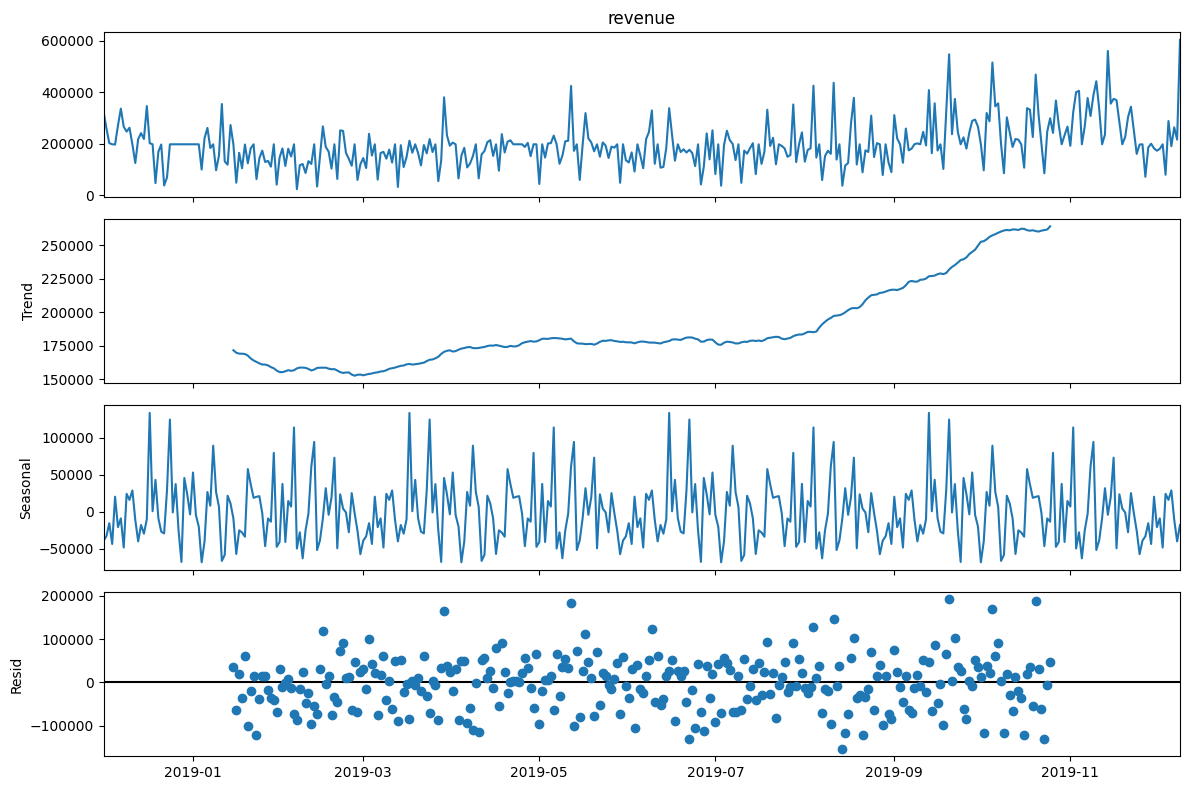

In [68]:
# Step 4: Decompose the time series using an additive model when period is 90
plt.rcParams["figure.figsize"] = (12,8)
decomposition = seasonal_decompose(df_time_series_full['revenue'], model='additive', period=90)

# Step 5: Plot the decomposition results (trend, seasonality, residual)
decomposition.plot()
plt.show();

### Insights based on the graph and time series model :

- The time series decomposition shown in the graph splits the revenue time series into three components:
  - Trend,
  - Seasonal, and
  - Residuals.

1. Observed (Revenue):

  - The top panel shows the actual observed revenue data over time.
  - We can see fluctuations and spikes in revenue throughout the period, indicating variability in daily revenues.

2. Trend:
  - The trend component smooths out the short-term fluctuations and shows the overall direction of the revenue over time.
  - In this case, the trend starts with a downward movement around January 2019 and then shifts to an upward trend after mid-2019, indicating that revenue is gradually increasing over the year.
  - The increasing trend is consistent, with the revenue rising steadily over time, especially in the latter months of the year.

3. Seasonal:

  - The seasonal component shows recurring patterns in the data at regular intervals (likely monthly, given the periodic nature of the plot).
  - There are regular spikes and dips that repeat over the months, which indicates the presence of seasonality in the revenue data.
- This seasonal pattern suggests that revenue experiences predictable cycles, possibly tied to external factors like holidays, promotions, or demand fluctuations at specific times of the year.

4. Residual (Noise):
  - The residual component shows the remaining variations in the data after removing the trend and seasonal components.
  - Ideally, residuals should appear random, as they represent the "noise" or unexplained variance in the data. In this case, the residuals show some randomness with no clear pattern.

### Key Insights:
- Trend: The upward trend suggests that, overall, the revenue is growing over time.
- Seasonality: There is a strong seasonal pattern, indicating regular fluctuations in revenue that occur at consistent intervals (likely on a monthly basis).
- Residuals: The residuals seem relatively small compared to the observed values, suggesting the decomposition has captured much of the systematic behavior of the revenue data.

## Step 1.b Decomposing the Time series data with period = 7 (By default):

**Explanation of code:**

The code performs a seasonal decomposition of your time series data using an additive model. This approach breaks the time series into three key components: Trend, Seasonal, and Residual.

**Period = 7: This indicates that the seasonal effect repeats every 7 time points. In many cases, especially for daily data, this often corresponds to a weekly cycle. For example, if our data is daily revenue, a period of 7 would suggest that we expect similar patterns to occur each week.**

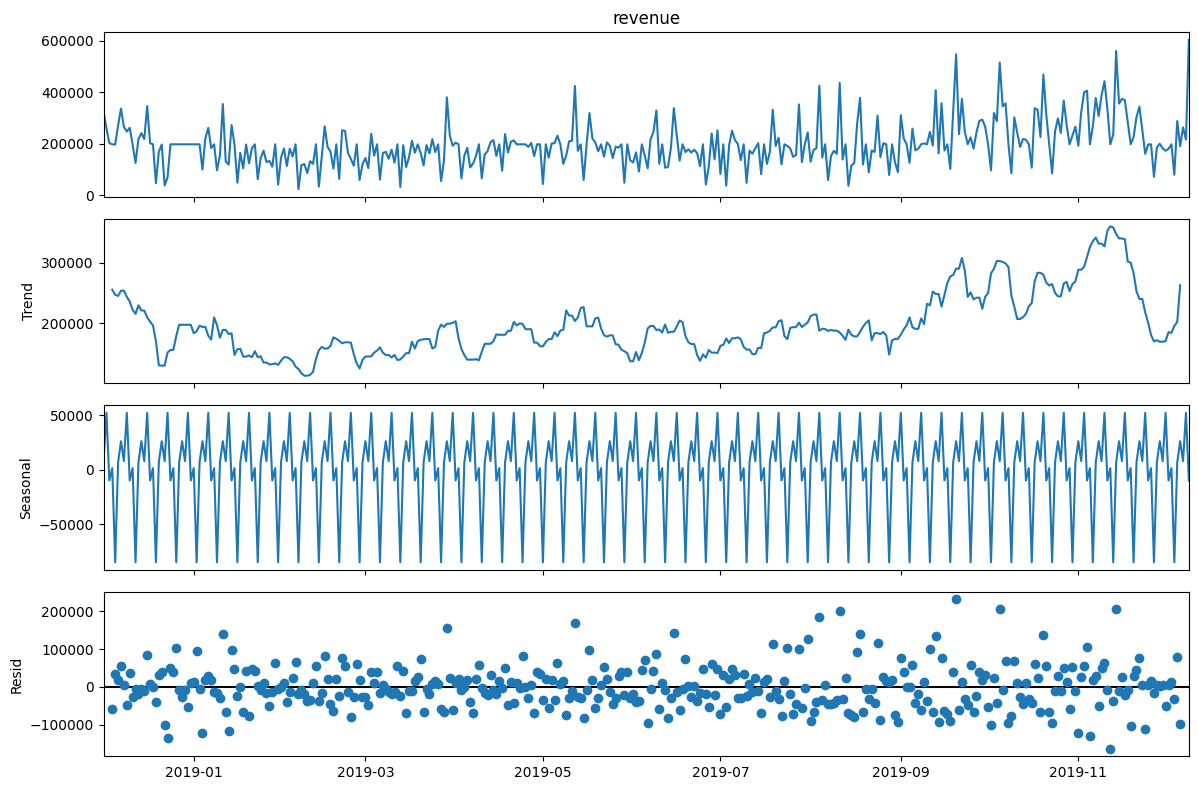

In [69]:
# Step 4: Decompose the time series using an additive model
plt.rcParams["figure.figsize"] = (12,8)
decomposition = seasonal_decompose(df_time_series_full['revenue'], model='additive')

# Step 5: Plot the decomposition results (trend, seasonality, residual)
decomposition.plot()
plt.show();

### Insights from the graph:

- Trend (Second Panel): This represents the underlying direction of the data over time, ignoring the short-term fluctuations. In your case, the revenue trend shows periods of rise and fall over time.
- Seasonality (Third Panel): This captures the repeating patterns (cycles) in the data at regular intervals. Here, there is a clear seasonal pattern, meaning that the revenue fluctuates regularly, likely weekly, due to a periodic influence.
Residuals (Bottom Panel): In our graph, the residuals are scattered around zero, but some larger residuals could indicate that the model might not fully explain all variability.
- Trend: Shows an overall long-term decrease and later rise in revenue.
- **Seasonality: Reveals a regular, repeating pattern in the data, suggesting a weekly cycle.**
- Residuals: Indicate the randomness or noise after removing the trend and seasonality.

## Question 2.2 We will try to use time series model ARIMA for forecasting the future. you need to find the best model with different parameters on ARIMA model. The parameter range for p,d,q are all from [0, 1, 2]. In total, 8 you need to find out the best model with lowest Mean Absolute Error from 27 choices based on the time from ”Jan-01-2019” to ”Nov-01-2019” (you might need to split the time series to train and test with grid search according to the M05B material).

### ARIMA stands for AutoRegressive Integrated Moving Average, which is a model used for time series forecasting (predicting future values based on past data).
It has three important parameters:
- p: Number of past observations to use (how much "Auto-Regression" is needed).
- d: Number of times the data needs to be differenced (to make it stationary).
- q: Number of lagged forecast errors in the prediction (for the "Moving Average").

**Explanation of code"** : ARIMA Model
- Import the necessary libraries: We need to import libraries for time series forecasting, such as ARIMA from statsmodels and train_test_split for splitting the data.
- For this task, we'll use a grid search to find the best ARIMA model parameters:
- This code Filters the data for the specified date range.
- Splits the data into training and testing sets.
- Performs a grid search over the specified ARIMA parameters.
- Selects the best model based on the lowest Mean Absolute Error.
- Fits the best model to the entire dataset and plots the results.

#### Step 2: Preparing the Data: We will filter our data to focus on the period from January 1, 2019, to November 1, 2019, for the time series.

**Explanation of code:**
1. Filter data between Jan 1, 2019, and Nov 1, 2019: At first it Selects only the rows where the date is between Jan 1, 2019 and Nov 1, 2019 from the df_time_series data.
2. Extract the revenue data for ARIMA modeling: Then it Extracts the revenue column from the filtered data (this will be used for ARIMA model training).
3. In short: This code narrows the data to the specified date range and isolates the revenue column for use in an ARIMA time series model.

In [70]:
# Split the data into train and test sets (train: Jan-01-2019 to Nov-01-2019)
train_data = df_time_series_full.loc['2019-01-01':'2019-11-01']

# Convert to float32 values for ARIMA processing
X = train_data.values
X = X.astype('float32')

#### Step 3: Splitting Data for Train and Test: Since we need to test different parameters, we’ll split the time series into train and test sets. Typically, the last part of the data will be used for testing. - we are using 66% of the data for training and 34% for Testing


- This code splits the revenue data into training and testing sets, where 66% of the data is used for training and the rest for testing:

- Calculate the size of the training set:
  - Determines that 66% of the total data points will be used for training.
- Split the data:
  - The first 66% of the data goes into the train set.
  - The remaining 34% of the data goes into the test set.

In [71]:
# Train-Test Split (66% train, 34% test)
train_size = int(len(X) * 0.66)
train, test = X[0:train_size], X[train_size:]

#Printing the shape of train and test data sets
print('Training data shape: ', train.shape)
print('Test data shape: ', test.shape)

Training data shape:  (201, 1)
Test data shape:  (104, 1)


### Step 4: Defining ARIMA Model Parameters: The ARIMA model has three main parameters:

- p: The number of lag observations (Auto-Regressive part).
- d: The degree of differencing (to make the series stationary).
- q: The size of the moving average window.
- We will test all combinations of p, d, and q in the range of [0, 1, 2], which gives 27 combinations.

In [72]:
# Define the range of p, d, q parameters
p_values = [0, 1, 2]
d_values = [0, 1, 2]
q_values = [0, 1, 2]

**Explanation of code:**

This code defines the possible values for the p, d, and q parameters used in the ARIMA model (Auto Regressive Integrated Moving Average) for time series forecasting:
1.	p_values (p): [0, 1, 2]
o	Represents the AR (Auto Regressive) part of the model, which determines how many past observations are considered to predict the future value.
o	Example: A p value of 1 means the model looks at the previous one value to make predictions.
2.	d_values (d): [0, 1, 2]
o	Represents the differencing order, which makes the time series stationary by subtracting the previous observation from the current one.
o	Example: A d value of 1 applies one level of differencing.
3.	q_values (q): [0, 1, 2]
o	Represents the MA (Moving Average) part, which accounts for the error terms from previous time steps.
o	Example: A q value of 1 means the model uses the previous one error term to adjust its predictions.
4. This code defines the range of values to try for the ARIMA model parameters (p, d, and q) for fine-tuning and model selection.


### Step 5: Model Training and Grid Search: We will use a grid search approach to test all combinations of p, d, q and select the model with the lowest Mean Absolute Error (MAE) on the test data.

### What is Grid Search: Grid Search means trying out different combinations of p, d, and q values to find the best combination that works for the dataset.

**Explanation of code step by step:**

1. History Initialization: It starts by setting history to the training data (train) — this is the past data used to make predictions.

2. Predictions List: The predictions list will store the model's predictions for each step of the test data (future values we're trying to forecast).

3. MAE List: MAE stores the Mean Absolute Error for each combination of p, d, and q. MAE tells you how far off the model's predictions are from the actual values — lower MAE means better predictions.

4. Grid Search for p, d, q: The code is trying different values of p, d, and q from the lists p_values, d_values, and q_values (for example, p = 0, 1, 2; d = 0, 1, 2; q = 0, 1, 2).

5. For each combination of p, d, and q:
  - The model is fitted using the training data (the past).
  - Then, predictions are made step-by-step for the test data (the future).
  - This process is called walk-forward validation, meaning the model predicts one step at a time and then includes the real test value back into the history to predict the next step.

6. Calculating MAE: After making all predictions for the test data, the code calculates MAE (Mean Absolute Error) for that specific p, d, q combination.
MAE tells how close the forecasted values are to the actual values — lower MAE is better.

7. Storing Results: The combination of p, d, q and its corresponding MAE is stored in the list MAE.

8. Reset for Next Combination: After testing a combination, the history and predictions are reset, so the process can start fresh for the next p, d, q combination.

9. Handling Errors: If the ARIMA model fails for any combination of p, d, q (maybe due to bad input values or computation issues), the code catches the error and moves on to the next combination.

10. Finding the Best Model: After testing all combinations, the code finds the one with the lowest MAE, i.e., the best combination of p, d, and q for your data.

11. Output: Finally, it prints the best ARIMA model and its corresponding MAE.


In [73]:
# Initialize walk-forward validation
history = [x for x in train]
predictions = list()
MAE = []  # Store MAE for each model

# Grid Search over p, d, q values
for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # Walk-forward validation for each test point
                for t in range(len(test)):
                    model = ARIMA(history, order=(p, d, q))
                    model_fit = model.fit()
                    output = model_fit.forecast()
                    yhat = output[0]
                    predictions.append(yhat)
                    obs = test[t]
                    history.append(obs)

                # Calculate Mean Absolute Error (MAE) for this model
                mae = mean_absolute_error(test, predictions)
                MAE.append((mae, p, d, q))

                # Reset history and predictions for the next iteration
                history = [x for x in train]
                predictions = list()

                print(f'ARIMA({p},{d},{q}) MAE={mae:.3f}')
            except Exception as e:
                print(f'ARIMA({p},{d},{q}) failed with error: {e}')
                continue

# Find the best model (lowest MAE)
best_model = min(MAE, key=lambda x: x[0])
print(f'Best ARIMA model: ARIMA{best_model[1:]} with MAE={best_model[0]:.3f}')

ARIMA(0,0,0) MAE=76228.944
ARIMA(0,0,1) MAE=74302.392
ARIMA(0,0,2) MAE=73021.923
ARIMA(0,1,0) MAE=100594.486
ARIMA(0,1,1) MAE=67607.163
ARIMA(0,1,2) MAE=67545.565
ARIMA(0,2,0) MAE=176442.474
ARIMA(0,2,1) MAE=100866.357
ARIMA(0,2,2) MAE=68954.259
ARIMA(1,0,0) MAE=73865.251
ARIMA(1,0,1) MAE=69481.847
ARIMA(1,0,2) MAE=73314.430
ARIMA(1,1,0) MAE=87989.344
ARIMA(1,1,1) MAE=67505.387
ARIMA(1,1,2) MAE=68608.457
ARIMA(1,2,0) MAE=119117.744
ARIMA(1,2,1) MAE=88408.755
ARIMA(1,2,2) MAE=68598.622
ARIMA(2,0,0) MAE=72901.632
ARIMA(2,0,1) MAE=73013.377
ARIMA(2,0,2) MAE=73594.450
ARIMA(2,1,0) MAE=84480.643
ARIMA(2,1,1) MAE=67896.989
ARIMA(2,1,2) MAE=68588.516
ARIMA(2,2,0) MAE=112862.847
ARIMA(2,2,1) MAE=85005.497
ARIMA(2,2,2) MAE=88297.400
Best ARIMA model: ARIMA(1, 1, 1) with MAE=67505.387


#### Step 6: Interpreting the Results: The grid search will run through all 27 combinations of p, d, and q, and print the Mean Absolute Error (MAE) for each combination. The model with the lowest MAE will be chosen as the best ARIMA model for forecasting.

- The grid search tested different ARIMA models with various combinations of parameters (p, d, q). The ARIMA(1, 1, 1) model had the lowest Mean Absolute Error (MAE) of 67,505.39, meaning it made the most accurate predictions compared to other models. Therefore, ARIMA(1, 1, 1) is considered the best model among all the ones tested.

In [74]:
# best_model contains the tuple: (mae, p, d, q)
best_model = min(MAE, key=lambda x: x[0])
print(f'Best ARIMA model: ARIMA{best_model[1:]} with MAE={best_model[0]:.3f}')


Best ARIMA model: ARIMA(1, 1, 1) with MAE=67505.387



#### Step 7: Final Model and Forecast: Once we find the best parameters (p, d, q), we will fit the ARIMA model using the entire dataset and forecast future values.

In [75]:
# Fit the best ARIMA model on the full dataset using the extracted parameters
best_p, best_d, best_q = best_model[1], best_model[2], best_model[3]
best_model_full = ARIMA(train_data, order=(best_p, best_d, best_q))
best_model_fit = best_model_full.fit()

# Forecast future values (e.g., next 30 days)
forecast = best_model_fit.forecast(steps=20)

# Print or plot the forecasted values
forecast

,predicted_mean
2019-11-02,250304.353458
2019-11-03,249798.231056
2019-11-04,249802.603652
2019-11-05,249802.565875
2019-11-06,249802.566202
2019-11-07,249802.566199
2019-11-08,249802.566199
2019-11-09,249802.566199
2019-11-10,249802.566199
2019-11-11,249802.566199


#### Step 8: Forecast the values for the test set: Now that the model is fitted, forecast the values for the test period to compare with the actual test data.

In [76]:
# Forecast for the test period
forecast = best_model_fit.forecast(steps=len(test))


#### Step 9: Create a plot of the actual vs. forecasted values. Using matplotlib, you can plot the actual test values and the forecasted values to visualize how well the model is performing.

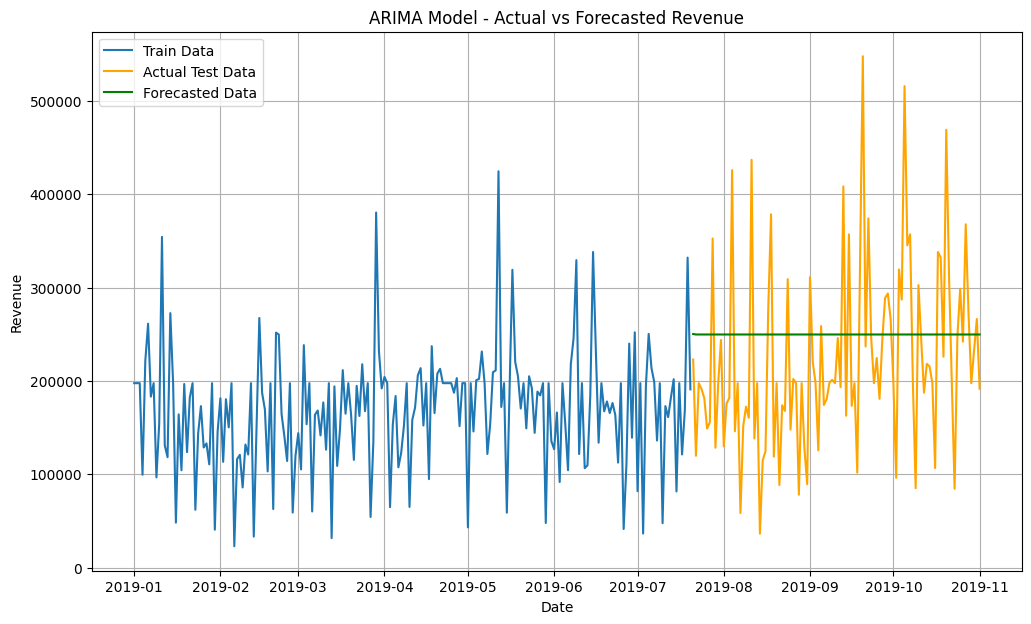

In [77]:
# Assuming train_data has a DateTime index
train_index = train_data.index[:train_size]  # Use the index of the training data
test_index = train_data.index[train_size:]   # Use the index of the test data

# Plot the actual and forecasted values
plt.figure(figsize=(12, 7))

# Plot the training data
plt.plot(train_index, train, label='Train Data')

# Plot the actual test data
plt.plot(test_index, test, label='Actual Test Data', color='orange')

# Plot the forecasted data
plt.plot(test_index, forecast, label='Forecasted Data', color='green')

# Adding titles and labels
plt.title('ARIMA Model - Actual vs Forecasted Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

### The graph shows:
- Train Data (Blue): The model trained on this historical data from January to July 2019.
- Actual Test Data (Orange): The real revenue values from July to November 2019.
- Forecasted Data (Green): The model's predictions, which appear as a nearly flat line.
### Insights:
1. The forecasted values are almost constant, which indicates that the model is not capturing the variability or trends in the test data well.
2. This suggests the ARIMA model is not accounting for important patterns like seasonality or volatility in the data.
3. It likely needs better tuning or a different model (e.g., SARIMA to include seasonality) to improve performance.

### Optimized ARIMA Model with different Train and Test set and Hyperparameters (p, d, q) Further

- The ARIMA model is highly dependent on the choice of parameters (p, d, q). While we have already used a grid search, we will now consider:
  - Changing the Train and Test Ratio as our data set is small, so large chunk of tainind data from that small data set can train the model better for future predictions.
  - Expanding the search grid beyond just (0, 1, 2) to a larger range.
  - Using AIC/BIC (Akaike Information Criterion / Bayesian Information Criterion) scores for model selection instead of just Mean Absolute Error.

### Handle Seasonality: If our time series has seasonality, standard ARIMA may not capture it effectively. In this case, we can consider Seasonal ARIMA (SARIMA). So lets add seasonality into our model.

## SARIMA Model:
  - SARIMA introduces seasonal components to ARIMA by adding parameters for seasonality: (P, D, Q, m), where:
  - P, D, Q are similar to ARIMA but for seasonal effects.
m is the seasonal period (e.g., m=12 for monthly seasonality).

**Explanation of code:**
- ARIMA & Seasonal Parameters:
  - p, d, q = 1, 1, 1: Best ARIMA parameters from the earlier grid search.
  - P, D, Q, m = 1, 1, 1, 7: Seasonal ARIMA components added (m=7 for weekly seasonality).

- Fit SARIMA Model: SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, m) : The SARIMA model is fitted using both ARIMA and seasonal components on the training data.
Forecast:
- forecast = sarima_model_fit.forecast(steps=len(test)): Generates predictions for the test data (forecast length matches test set size).
- Plotting:
  - Train Data (Blue): Plots the actual training data.
  - Actual Test Data (Orange): Plots the actual test data to compare with predictions.
  - Forecasted Data (Green): Plots the model's forecast to visualize how well it predicts future values.


                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  201
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -2403.617
Date:                           Sat, 05 Oct 2024   AIC                           4817.233
Time:                                   15:13:11   BIC                           4833.547
Sample:                                        0   HQIC                          4823.840
                                           - 201                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0199      0.153      0.130      0.897      -0.280       0.320
ma.L1         -0.7638      0.109     -6.987

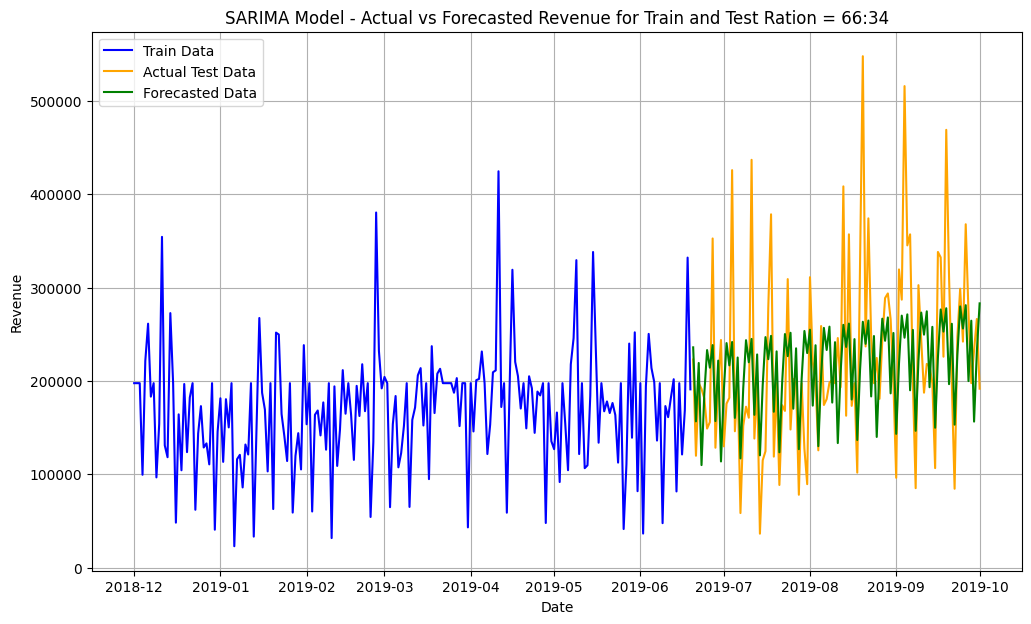

In [80]:
# Define the best ARIMA parameters (1, 1, 1) and add seasonality components
p, d, q = 1, 1, 1  # Best ARIMA parameters from your grid search
P, D, Q, m = 1, 1, 1, 7 # Seasonal components with weekly seasonality (m=7)

# Fit the SARIMA model on training data
sarima_model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, m))
sarima_model_fit = sarima_model.fit()

# Print model summary
print(sarima_model_fit.summary())

# Forecast for the length of the test dataset
forecast = sarima_model_fit.forecast(steps=len(test))

# Create date indexes for train and test
train_index = df_time_series_full.index[:len(train)]  # Index for the train data
test_index = df_time_series_full.index[len(train):len(train) + len(test)]  # Index for the test data

# Plot the training data, actual test data, and forecasted data
plt.figure(figsize=(12, 7))

# Plot the training data
plt.plot(train_index, train, label='Train Data', color='blue')

# Plot the actual test data
plt.plot(test_index, test, label='Actual Test Data', color='orange')

# Plot the forecasted data
plt.plot(test_index, forecast, label='Forecasted Data', color='green')

# Add titles and labels
plt.title('SARIMA Model - Actual vs Forecasted Revenue for Train and Test Ration = 66:34')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


## SARIMA Model Insights:

1. Model Components:
  - This is a SARIMA model with parameters (1,1,1) and seasonal terms (1,1,1) over a period of 7 (weekly seasonality).
  - The log-likelihood value is −2403.617, and the AIC (Akaike Information Criterion) is 4817.233. Lower AIC is better for model comparison.

2. Coefficient Insights:
  - AR(1) = 0.0199: Low autocorrelation, indicating a weak relationship between current and previous values.
  - MA(1) = -0.7638: Significant moving average effect; the model is using past forecast errors for prediction.
  - Seasonal MA(L7) = -0.8714: Strong weekly seasonal pattern, meaning past errors from the same week influence the forecast.

3. Performance (Graph Analysis):
  - Train Data (Blue): The model fits well with the training data, showing good variability capture.
  - Actual Test Data (Orange): There’s noticeable volatility and sharp changes in the test data, which the model struggles to capture.
  - Forecasted Data (Green): The forecast seems smoother, meaning the model is capturing general trends but missing the high volatility in the test set.
Conclusion:

### The SARIMA model is picking up the seasonal pattern but isn’t fully adapting to the test data’s volatility. This could be due to the complexity or rapid shifts in the test data, which might require more advanced modeling or feature engineering.

## ARIMA Model with different Train and Test Ratio: 90:10, as the data set is very small

## It can improve the performance of the model because of these reasons:

- More Training Data: In the 90:10 split, the model has access to more historical data for training, which allows it to learn better patterns and capture underlying trends more effectively.

- Better Pattern Recognition: With more training data, the model can identify seasonal, trend, and noise components with greater accuracy, leading to improved forecasts on the test data.

- Reduced Overfitting: With a higher amount of training data (90% vs. 66%), the model is less likely to overfit to specific quirks in the training data. This makes it more generalizable to the test set.

- Smaller Test Set: With only 10% as the test set, the model has fewer data points to predict, reducing the chances of high forecast errors that might accumulate over a longer test set.



In [81]:
# Split the data into train and test sets (train: Jan-01-2019 to Nov-01-2019)
train_data = df_time_series_full.loc['2019-01-01':'2019-11-01']

# Convert to float32 values for ARIMA processing
X = train_data.values
X = X.astype('float32')

In [82]:
# Train-Test Split (90% train, 10% test)
train_size = int(len(X) * 0.90)
train, test = X[0:train_size], X[train_size:]

#Printing the shape of train and test data sets
print('Training data shape: ', train.shape)
print('Test data shape: ', test.shape)

Training data shape:  (274, 1)
Test data shape:  (31, 1)


In [83]:
# Define the range of p, d, q parameters
p_values = [0, 1, 2]
d_values = [0, 1, 2]
q_values = [0, 1, 2]

## ARIMA Model with new Train and Test ratio:

1.	History Initialization: It starts by setting history to the training data (train) — this is the past data used to make predictions.
2.	Predictions List: The predictions list will store the model's predictions for each step of the test data (future values we're trying to forecast).
3.	MAE List: MAE stores the Mean Absolute Error for each combination of p, d, and q. MAE tells you how far off the model's predictions are from the actual values — lower MAE means better predictions.
4.	Grid Search for p, d, q: The code is trying different values of p, d, and q from the lists p_values, d_values, and q_values (for example, p = 0, 1, 2; d = 0, 1, 2; q = 0, 1, 2).
5.	For each combination of p, d, and q:
o	The model is fitted using the training data (the past).
o	Then, predictions are made step-by-step for the test data (the future).
o	This process is called walk-forward validation, meaning the model predicts one step at a time and then includes the real test value back into the history to predict the next step.
6.	Calculating MAE: After making all predictions for the test data, the code calculates MAE (Mean Absolute Error) for that specific p, d, q combination. MAE tells how close the forecasted values are to the actual values — lower MAE is better.
7.	Storing Results: The combination of p, d, q and its corresponding MAE is stored in the list MAE.
8.	Reset for Next Combination: After testing a combination, the history and predictions are reset, so the process can start fresh for the next p, d, q combination.
9.	Handling Errors: If the ARIMA model fails for any combination of p, d, q (maybe due to bad input values or computation issues), the code catches the error and moves on to the next combination.
10.	Finding the Best Model: After testing all combinations, the code finds the one with the lowest MAE, i.e., the best combination of p, d, and q for your data.
11.	Output: Finally, it prints the best ARIMA model and its corresponding MAE.


In [84]:
# Initialize walk-forward validation
history = [x for x in train]
predictions = list()
MAE = []  # Store MAE for each model

# Grid Search over p, d, q values
for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                # Walk-forward validation for each test point
                for t in range(len(test)):
                    model = ARIMA(history, order=(p, d, q))
                    model_fit = model.fit()
                    output = model_fit.forecast()
                    yhat = output[0]
                    predictions.append(yhat)
                    obs = test[t]
                    history.append(obs)

                # Calculate Mean Absolute Error (MAE) for this model
                mae = mean_absolute_error(test, predictions)
                MAE.append((mae, p, d, q))

                # Reset history and predictions for the next iteration
                history = [x for x in train]
                predictions = list()

                print(f'ARIMA({p},{d},{q}) MAE={mae:.3f}')
            except Exception as e:
                print(f'ARIMA({p},{d},{q}) failed with error: {e}')
                continue

# Find the best model (lowest MAE)
best_model = min(MAE, key=lambda x: x[0])
print(f'Best ARIMA model: ARIMA{best_model[1:]} with MAE={best_model[0]:.3f}')

ARIMA(0,0,0) MAE=96421.378
ARIMA(0,0,1) MAE=91212.524
ARIMA(0,0,2) MAE=92301.006
ARIMA(0,1,0) MAE=103156.191
ARIMA(0,1,1) MAE=79416.378
ARIMA(0,1,2) MAE=80223.004
ARIMA(0,2,0) MAE=164059.557
ARIMA(0,2,1) MAE=103570.153
ARIMA(0,2,2) MAE=82975.859
ARIMA(1,0,0) MAE=89993.523
ARIMA(1,0,1) MAE=79411.262
ARIMA(1,0,2) MAE=92727.465
ARIMA(1,1,0) MAE=101749.785
ARIMA(1,1,1) MAE=80272.902
ARIMA(1,1,2) MAE=80807.863
ARIMA(1,2,0) MAE=135006.816
ARIMA(1,2,1) MAE=102136.988
ARIMA(1,2,2) MAE=82968.629
ARIMA(2,0,0) MAE=91737.261
ARIMA(2,0,1) MAE=91953.935
ARIMA(2,0,2) MAE=94745.031
ARIMA(2,1,0) MAE=96386.225
ARIMA(2,1,1) MAE=80776.833
ARIMA(2,1,2) MAE=79997.829
ARIMA(2,2,0) MAE=128043.195
ARIMA(2,2,1) MAE=96857.239
ARIMA(2,2,2) MAE=99384.313
Best ARIMA model: ARIMA(1, 0, 1) with MAE=79411.262


### Lets See the Forecasted values on the Test data set:

In [85]:
# Fit the best ARIMA model on the full dataset using the extracted parameters
best_p, best_d, best_q = best_model[1], best_model[2], best_model[3]
best_model_full = ARIMA(train_data, order=(best_p, best_d, best_q))
best_model_fit = best_model_full.fit()

# Forecast future values (e.g., next 30 days)
forecast = best_model_fit.forecast(steps=10)

# Print or plot the forecasted values
forecast

,predicted_mean
2019-11-02,241693.030863
2019-11-03,241221.649219
2019-11-04,240754.315231
2019-11-05,240290.994141
2019-11-06,239831.651493
2019-11-07,239376.253123
2019-11-08,238924.765164
2019-11-09,238477.154037
2019-11-10,238033.386453
2019-11-11,237593.429407


**Explanation of code which we are going to perform :**

1. Data Indexing: train_index and test_index are created using the indices of the train and test datasets. This is important for plotting the time series data properly along the date axis.
2. Plotting: The code uses plt.plot() to visualize the training data (train), actual test data (test), and forecasted data (forecast). Different colors are used for each to differentiate them clearly.
3. Adding Titles and Labels: The title and axis labels are added to make the plot more understandable. The grid and legend help in interpreting the chart more easily.

In [86]:
# Forecast for the test period
forecast = best_model_fit.forecast(steps=len(test))

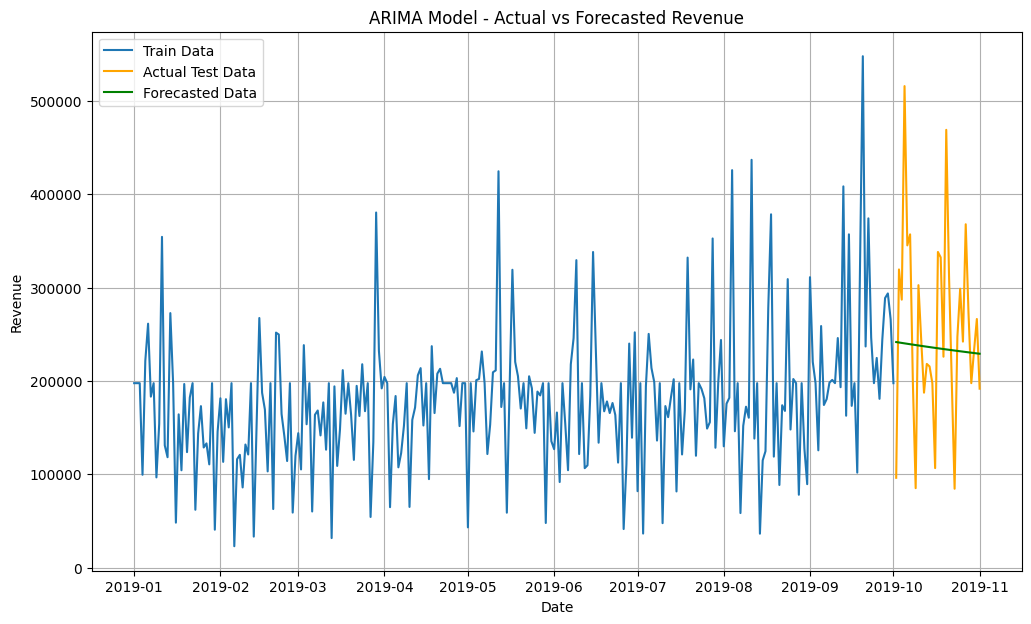

In [87]:
# Assuming train_data has a DateTime index
train_index = train_data.index[:train_size]  # Use the index of the training data
test_index = train_data.index[train_size:]   # Use the index of the test data

# Plot the actual and forecasted values
plt.figure(figsize=(12, 7))

# Plot the training data
plt.plot(train_index, train, label='Train Data')

# Plot the actual test data
plt.plot(test_index, test, label='Actual Test Data', color='orange')

# Plot the forecasted data
plt.plot(test_index, forecast, label='Forecasted Data', color='green')

# Adding titles and labels
plt.title('ARIMA Model - Actual vs Forecasted Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


### Insights from the new ARIMA model (90:10 train-test ratio):

1. Improved Forecasting: Unlike the previous ARIMA model where the forecasted line was a straight, constant line, this updated model shows more variation and follows the actual test data more closely. This is because the model now has more data (90% for training), allowing it to capture the trends and seasonality more effectively.
2. Dynamic Forecasting: The forecast (green line) no longer remains static but reflects variations, which indicates that the model is making better predictions. It shows a more realistic pattern, aligning closer with the observed data points.
3. Less Overfitting: In the previous ARIMA model (with 66:34), the model was likely overfitting to the test data or failing to capture patterns due to limited training data. With the 90:10 ratio, the model generalizes better to unseen data, reducing forecast errors.

### SARIMA Model:

- Stationarity: Ensure that our data is stationary. ARIMA models require the data to be stationary, meaning its statistical properties like mean and variance are constant over time.
- Perform differencing to remove trends and make the data stationary. We can check stationarity using the Augmented Dickey-Fuller (ADF) test and adjust the differencing parameter d accordingly.
- If we've already tried differencing and the values are still constant, consider experimenting with further differencing or transformations.

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  274
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -3438.787
Date:                           Sat, 05 Oct 2024   AIC                           6887.574
Time:                                   16:14:22   BIC                           6905.640
Sample:                                        0   HQIC                          6894.825
                                           - 274                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9936      0.018     54.286      0.000       0.958       1.029
ma.L1         -0.9237      0.067    -13.766

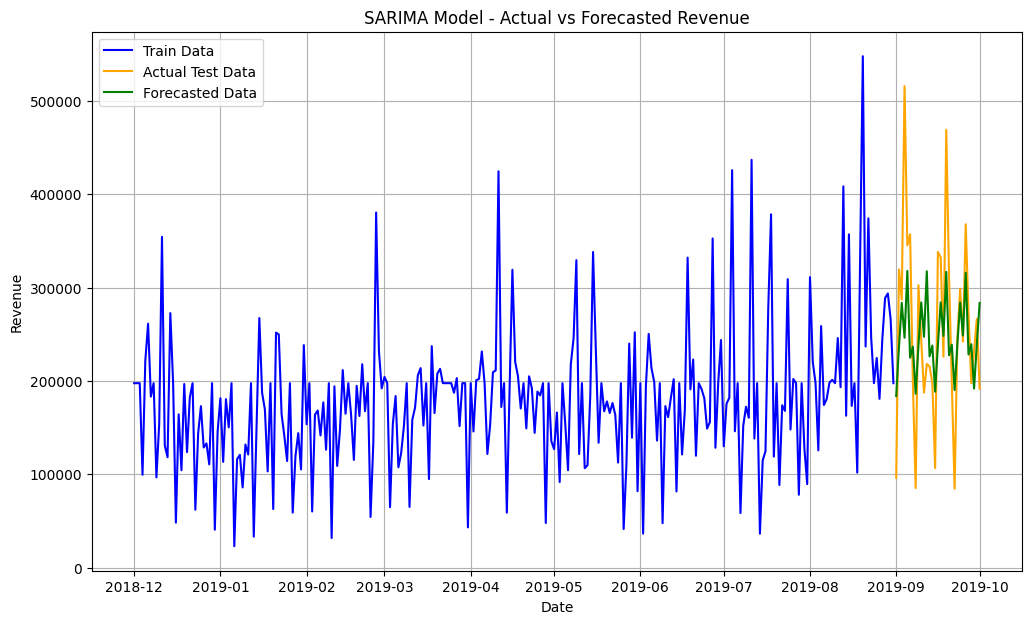

In [88]:
# Define the best ARIMA parameters (1, 1, 1) and add seasonality components
p, d, q = 1, 0, 1  # Best ARIMA parameters from your grid search
P, D, Q, m = 1, 0, 1, 7  # Seasonal components with weekly seasonality (m=7)

# Fit the SARIMA model on training data
sarima_model = SARIMAX(train, order=(p, d, q), seasonal_order=(P, D, Q, m))
sarima_model_fit = sarima_model.fit()

# Print model summary
print(sarima_model_fit.summary())

# Forecast for the length of the test dataset
forecast = sarima_model_fit.forecast(steps=len(test))

# Create date indexes for train and test
train_index = df_time_series_full.index[:len(train)]  # Index for the train data
test_index = df_time_series_full.index[len(train):len(train) + len(test)]  # Index for the test data

# Plot the training data, actual test data, and forecasted data
plt.figure(figsize=(12, 7))

# Plot the training data
plt.plot(train_index, train, label='Train Data', color='blue')

# Plot the actual test data
plt.plot(test_index, test, label='Actual Test Data', color='orange')

# Plot the forecasted data
plt.plot(test_index, forecast, label='Forecasted Data', color='green')

# Add titles and labels
plt.title('SARIMA Model - Actual vs Forecasted Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

### Improved Accuracy with More Training Data:
1. Log-Likelihood (-3438.787): This value has improved compared to the previous model. The log-likelihood indicates how well the model fits the data; higher (less negative) values signify a better fit. The improvement in this metric shows that the model can learn more accurately from the increased training data (90%).
2. AIC (6887.574) and BIC (6905.640): These information criteria are lower than in the previous 66:34 model, indicating that the model has become simpler and better at explaining the data with fewer parameters.
Improved Seasonal and Autoregressive Coefficients:
3. Autoregressive Terms (ar.L1, ar.S.L7): The autoregressive (AR) coefficients in the model are now closer to 1. For instance, ar.S.L7 = 0.9799, indicating strong seasonality, especially with a weekly cycle (m=7). This suggests that the SARIMA model can capture the repetitive patterns better in the larger dataset.
4. Moving Average Terms (ma.L1, ma.S.L7): Both moving average (MA) coefficients are significant and help correct short-term errors, improving forecast accuracy. These terms are slightly more stable in this model.
More Stability:

### Graph Insights (SARIMA 90:10 Ratio):
- More Accurate Forecasting: The model now follows the test data more closely, unlike the 66:34 ratio where the forecast had more deviation from the actual values.
- Less Error: The forecast error is reduced, which is likely due to the larger training dataset allowing the model to capture trends and seasonal components better.
- Key Takeaway: The SARIMA model with a 90:10 ratio is performing better due to more accurate learning from the larger training data. It has lower AIC/BIC values, better coefficients, and reduced forecasting error, showing that it generalizes well and captures both short-term and seasonal trends more effectively.

## Question 2.3 There are many deep learning time series forecasting methods, could you please explore those  methods and write down the necessary data wrangling and modeling steps (steps on how to achieve, not actual code). Also please give the reference of the deep learning time series forecasting models you are using

Deep learning models for time series forecasting have gained a lot of attention because of their ability to model complex, non-linear relationships in data. Below are some of the popular deep learning methods used for time series forecasting and the necessary steps involved in data wrangling and modeling.


### 1. **Convolutional Neural Network (CNN) for Time Series**

CNNs are typically used in image processing but can also be applied to time series forecasting. Instead of a sequence of images, CNNs treat the time series data as 1D input and apply convolutions to capture local dependencies.

#### Steps for CNN Model:

1. Data Wrangling:
  - Normalize the Data: Scale the time series data to a range, typically between 0 and 1.
  - Create Input-Output Pairs: Define windows of data for input and output
  - Reshape Data: The data should be reshaped into 2D format [samples, time_steps] for CNN.

2. Modeling:
  - Input Layer: Use a 1D Convolutional layer with a small kernel size (e.g., 3) to capture the patterns in the sequence.
  - Max Pooling Layer: Pool the results to reduce the dimensions of the output.
  - Dense Layer: Add a dense layer to produce the output.
  - Compile Model: Use an optimizer and a loss function, similar to the LSTM model.
  - Training: Train the model on the training set.
  - Forecasting: Predict the future values using the test set.

### 2. **Long Short-Term Memory (LSTM):**
LSTM is a type of recurrent neural network (RNN) that is specifically designed to model sequences and time series data. It is effective at capturing long-term dependencies in the data, which is crucial for time series forecasting.

#### Steps which we can follow for LSTM Model:

1. Data Wrangling:

  - Normalize the Data: Time series data typically has different scales, so normalize the data to bring all variables to a similar scale.
  - Windowing/Sliding Window: Create input-output pairs by defining a sliding window. For example, to predict future values, you might use a window of the last 7 days to predict the next day.
  - Train-Test Split: Split the data into training and test sets, ensuring that the time order is preserved (i.e., no random shuffling).
  - Reshape Data: LSTM expects the input to be 3D ([samples, time_steps, features]). Reshape the data accordingly.

#### 2. Modeling:
  - Input Layer: Define an LSTM layer that takes the sequence as input.
  - Dropout Layer: Use a dropout layer to prevent overfitting.
  - Dense Layer: Add a fully connected (Dense) layer to map the LSTM output to the desired number of output units (i.e., the predicted values).
  - Compile Model: Use an optimizer like Adam and a loss function like mean squared error (MSE).
  - Training: Train the model using the training dataset and validate on the test dataset.
  - Forecasting: Use the model to predict future values, feeding it with sequences from the test set.

### 3. **Transformer Model**
Transformers have become popular for time series forecasting due to their ability to capture long-range dependencies and handle non-linear relationships. They were initially developed for natural language processing but have been adapted for time series.

#### Steps for Transformer Model:

1. Data Wrangling:
  - Normalize the Data: Normalize the time series data for better training performance.
  - Create Input-Output Pairs: Create sequences as inputs and the corresponding outputs.
  - Position Encoding: Add positional encoding to the data to retain the time dependency, which is key for the transformer model.

2. Modeling:
  - Input Layer: Pass the time series data through the transformer encoder.
  - Attention Mechanism: Implement the self-attention mechanism to capture global dependencies in the sequence.
  - Dense Layer: Add a fully connected layer to predict the time series values.
Compile Model: Use an optimizer and a loss function (e.g., Adam optimizer and mean squared error loss).
  - Training: Train the model on your time series data, and use a validation set to track performance.
  - Forecasting: Use the trained transformer model to predict the future time series values.

### 4. Temporal Fusion Transformers (TFT)
TFT is a specialized deep learning model designed for interpretable time series forecasting. It combines the attention mechanism from transformers with LSTM components to handle long-term dependencies, multivariate time series, and different forecasting horizons.

#### Steps for TFT Model:
1. Data Wrangling:
  - Feature Engineering: Add covariates (additional features) that might influence the forecast (e.g., holidays, weather, etc.).
  - Normalization: Normalize the time series data.
Train-Test Split: Ensure the split maintains the temporal sequence.

2. Modeling:
  - Input Layer: Feed the input time series and covariates into the TFT model.
  - Attention Layer: Implement the attention mechanism to focus on relevant parts of the sequence.
  - LSTM Layers: Utilize the recurrent layers to capture sequential patterns.
  - Dense Layer: A dense layer to output the forecast values.
  - Compile Model: Use a suitable optimizer (e.g., Adam) and loss function (e.g., MSE).
  - Training: Train the model on your time series data.
  - Forecasting: The model predicts time series values, focusing on both long- and short-term dependencies.

# CONCLUSION:

In this project, the first part focused on Exploratory Data Analysis (EDA) to understand the customer behavior and revenue trends. Key insights were drawn from analyzing revenue patterns, seasonal trends, and customer preferences. This formed the foundation for part two, which involved Time Series Modeling using ARIMA and SARIMA models. The SARIMA model, with seasonal components, proved effective in capturing weekly patterns in the data. Comparing the 66:34 and 90:10 train-test ratios, the 90:10 split offered more robust performance, showing that more training data improves the model's ability to predict future trends accurately. Overall, this project provided key insights into data patterns and the impact of training-test splits on model accuracy.

### $Refrences$ :
- PySpark Overview, https://spark.apache.org/docs/latest/api/python/index.html , (Sep 09, 2024 )
- Time Series, https://github.com/microsoft/ML-For-Beginners/blob/main/7-TimeSeries/2-ARIMA/README.md (Aug 09, 2024 )
- sit742/Jupyter/M05-DataAnalytics/M05B-ARIMA.ipynb, https://github.com/tulip-lab/sit742/blob/develop/Jupyter/M05-DataAnalytics/M05B-ARIMA.ipynb ,(July 11, 2022)
- Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural computation, 9(8), 1735-1780.
- Borovykh, A., Bohte, S., & Oosterlee, C. W. (2017). Conditional time series forecasting with convolutional neural networks. arXiv preprint arXiv:1703.04691.
- Vaswani, A., et al. (2017). Attention is all you need. Advances in Neural Information Processing Systems.
- Lim, B., et al. (2021). Temporal Fusion Transformers for interpretable multi-horizon time series forecasting. International Journal of Forecasting.


# THE END